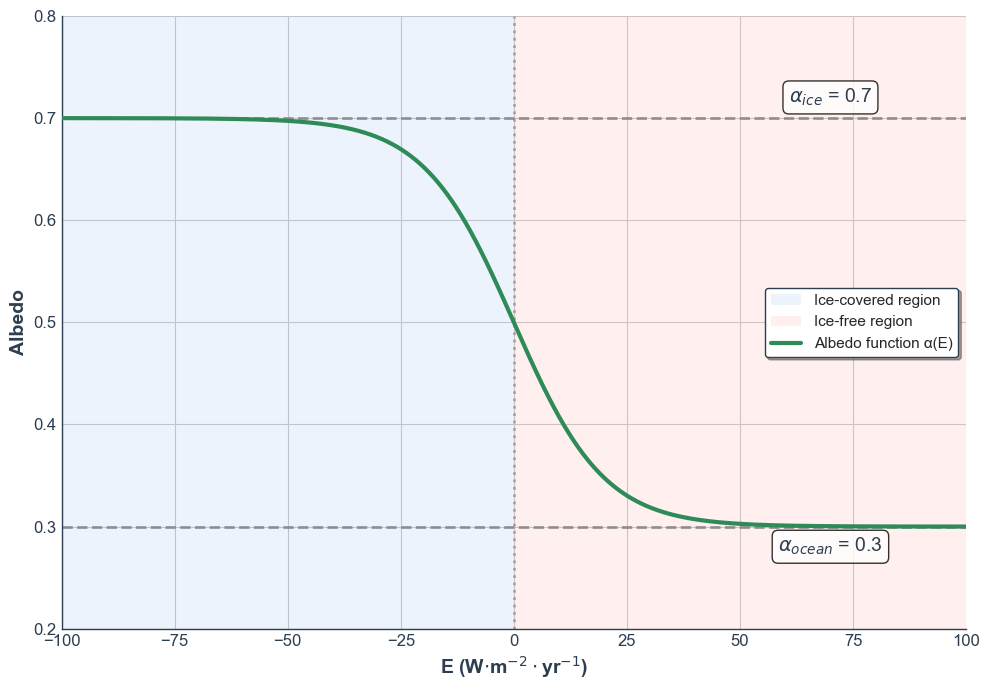

Key albedo values:
At E = -50: α = 0.697
At E = 0:   α = 0.500
At E = +50: α = 0.303


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap

# Set up a nice color scheme
plt.style.use('seaborn-v0_8-whitegrid')
colors = {
    'main_curve': '#2E8B57',      # Sea green
    'ice_region': '#4A90E2',      # Light blue
    'ocean_region': '#FF6B6B',    # Coral red
    'reference_lines': '#7F7F7F', # Gray
    'text': '#2C3E50'             # Dark blue-gray
}

# Parameters from the text
alpha_ice = 0.7      # albedo of sea ice
alpha_ocean = 0.3    # albedo of open ocean
delta_E = 10         # parameter controlling transition sharpness

# Create energy range (W⋅m⁻²⋅yr⁻¹)
E = np.linspace(-100, 100, 1000)

# Calculate albedo using the sigmoid function
# α(E) = α_ocean + (α_ice - α_ocean) / (1 + e^(E/ΔE))
alpha = alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

# Create the figure with enhanced styling
fig, ax = plt.subplots(figsize=(10, 7))

# Add background shading for ice and ocean regions
ice_patch = patches.Rectangle((-100, 0.2), 100, 0.6, 
                             facecolor=colors['ice_region'], alpha=0.1, 
                             label='Ice-covered region')
ocean_patch = patches.Rectangle((0, 0.2), 100, 0.6, 
                               facecolor=colors['ocean_region'], alpha=0.1, 
                               label='Ice-free region')
ax.add_patch(ice_patch)
ax.add_patch(ocean_patch)

# Plot the main curve with enhanced styling
ax.plot(E, alpha, color=colors['main_curve'], linewidth=3, 
        label='Albedo function α(E)', zorder=5)

# Add horizontal reference lines with better styling
ax.axhline(y=alpha_ice, color=colors['reference_lines'], 
           linestyle='--', alpha=0.8, linewidth=2)
ax.axhline(y=alpha_ocean, color=colors['reference_lines'], 
           linestyle='--', alpha=0.8, linewidth=2)

# Add labels for the reference lines with better positioning
ax.text(70, alpha_ice + 0.015, r'$\alpha_{ice}$ = 0.7', 
        fontsize=14, ha='center', color=colors['text'], 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.text(70, alpha_ocean - 0.025, r'$\alpha_{ocean}$ = 0.3', 
        fontsize=14, ha='center', color=colors['text'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Add a vertical line at E = 0 for reference
ax.axvline(x=0, color=colors['reference_lines'], linestyle=':', alpha=0.6, linewidth=2)

# Set axis labels and title with enhanced styling
ax.set_xlabel('E (W$\cdot$m$^{-2}\cdot$yr$^{-1}$)', fontsize=14, color=colors['text'], fontweight='bold')
ax.set_ylabel('Albedo', fontsize=14, color=colors['text'], fontweight='bold')
# ax.set_title('Albedo as a Function of Energy E\nClimate System Transition Model', 
#              fontsize=16, pad=20, color=colors['text'], fontweight='bold')

# Set axis limits and styling
ax.set_xlim(-100, 100)
ax.set_ylim(0.2, 0.8)

# Customize tick parameters
ax.tick_params(axis='both', which='major', labelsize=12, colors=colors['text'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(colors['text'])
ax.spines['bottom'].set_color(colors['text'])

# Add a subtle legend
ax.legend(loc='center right', frameon=True, fancybox=True, shadow=True, 
          fontsize=11, facecolor='white', edgecolor=colors['text'])

# # Add explanatory text with enhanced styling
# textstr = ('The sigmoid curve illustrates the smooth transition from high albedo\n'
#            '(α$_{ice}$ = 0.7) in ice-covered conditions to low albedo\n'
#            '(α$_{ocean}$ = 0.3) in ice-free conditions.\n\n'
#            'Transition controlled by ΔE = 10 W⋅m$^{-2}$⋅yr$^{-1}

# # Print key values for verification with enhanced formatting
# print("\n" + "="*50)
# print("🌡️  CLIMATE MODEL VERIFICATION")
# print("="*50)
# print("Key albedo values across energy spectrum:")
# print(f"📊 At E = -50 W⋅m⁻²⋅yr⁻¹: α = {alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(-50 / delta_E)):.3f} (ice-dominated)")
# print(f"📊 At E =   0 W⋅m⁻²⋅yr⁻¹: α = {alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(0 / delta_E)):.3f} (transition point)")
# print(f"📊 At E = +50 W⋅m⁻²⋅yr⁻¹: α = {alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(50 / delta_E)):.3f} (ocean-dominated)")
# print("\n💾 Figure saved as 'albedo_energy_figure.png'")
# print("="*50)

props = dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.9, 
             edgecolor=colors['main_curve'], linewidth=2)

# ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,verticalalignment='top', bbox=props, color=colors['text'])

# # Add annotations for key regions
# ax.annotate('Ice-covered\nregion', xy=(-50, 0.65), xytext=(-70, 0.55),
#             fontsize=12, ha='center', color=colors['ice_region'], fontweight='bold',
#             arrowprops=dict(arrowstyle='->', color=colors['ice_region'], lw=2))

# ax.annotate('Ice-free\nregion', xy=(50, 0.35), xytext=(70, 0.45),
#             fontsize=12, ha='center', color=colors['ocean_region'], fontweight='bold',
#             arrowprops=dict(arrowstyle='->', color=colors['ocean_region'], lw=2))

# Adjust layout and save/display
plt.tight_layout()

# Save as PNG with high resolution
plt.savefig('albedo_energy_figure.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none')
plt.show()

# Print some key values for verification
print("Key albedo values:")
print(f"At E = -50: α = {alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(-50 / delta_E)):.3f}")
print(f"At E = 0:   α = {alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(0 / delta_E)):.3f}")
print(f"At E = +50: α = {alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(50 / delta_E)):.3f}")

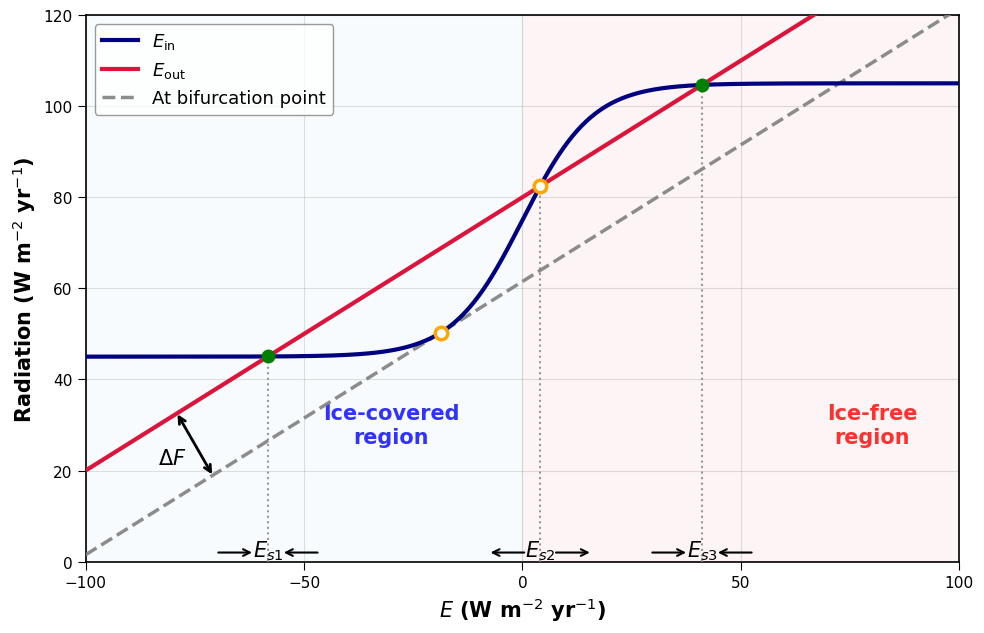

Tangency at E* = -18.74, Ein(E*) = 50.26,  ΔF_crit = 18.50 W m^-2 yr^-1


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# --- Clean styling to match reference ---
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

# Colors
c_ein   = '#000080'    # Navy blue
c_eout  = '#DC143C'    # Crimson red
c_dash  = '#808080'    # Gray
c_text  = '#000000'    # Black text
c_stable   = '#008000' # Green
c_unstable = '#FFA500' # Orange

# --- Model parameters ---
A = 80.0                  # W m^-2
B = 0.6                   # yr^-1
S = 150.0                 # W m^-2
alpha_ice, alpha_ocean = 0.7, 0.3
delta_E = 8.0             # transition sharpness

# main (red) case shift
delta_F = 0.0

# --- Helper functions ---
E = np.linspace(-100, 100, 1201)

def albedo(E):
    # logistic transition from ice to ocean
    return alpha_ocean + (alpha_ice - alpha_ocean) / (1.0 + np.exp(E/delta_E))

def Ein(E):
    return (1.0 - albedo(E)) * S

def dEin_dE(E):
    # derivative of Ein wrt E
    # d alpha / dE = (alpha_ice - alpha_ocean) * [ -(exp(E/dE)/(1+exp(E/dE))^2) * (1/dE) ]
    z = np.exp(E/delta_E)
    dalpha_dE = (alpha_ice - alpha_ocean) * (-(z / (1.0 + z)**2)) * (1.0/delta_E)
    return -dalpha_dE * S  # because Ein = (1 - alpha)*S

def Eout(E, dF=0.0):
    return A + B*E - dF

# steady-state residual for the main (red) case
def resid(Eval):
    return Ein(Eval) - Eout(Eval, delta_F)

# --- Find the 3 intersections for the main case ---
guesses = [-55, -5, 42]
roots = []
for g in guesses:
    r = fsolve(resid, g, xtol=1e-12)[0]
    if -100 <= r <= 100:
        roots.append(r)
roots = sorted(roots)
ys = [Ein(r) for r in roots]
stability = ['stable', 'unstable', 'stable']  # by geometry (left->right)

# --- Compute the bifurcation (tangency) case automatically ---
# Solve dEin/dE(E*) = B for E* near the middle root; fall back through several guesses.
def solve_tangency():
    for g in [0, -10, 10, 20, -20, 30, -30]:
        try:
            root = fsolve(lambda e: dEin_dE(e) - B, g, xtol=1e-12)[0]
            if -100 <= root <= 100:
                return root
        except Exception:
            pass
    # last-resort: return the middle equilibrium as a reasonable seed
    return roots[1] if len(roots) == 3 else 0.0

E_tan = solve_tangency()              # tangency abscissa
Ein_tan = Ein(E_tan)                  # Ein at tangency
delta_F_crit = A + B*E_tan - Ein_tan  # shift so Eout passes through (E_tan, Ein_tan)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6.5))

# light background
ax.axvspan(-100, 0, alpha=0.08, color='lightblue',  zorder=1)
ax.axvspan(0,   100, alpha=0.08, color='lightcoral', zorder=1)

# curves
ax.plot(E, Ein(E),              color=c_ein,  lw=3, zorder=5, label=r'$E_{\mathrm{in}}$')
ax.plot(E, Eout(E, delta_F),    color=c_eout, lw=3, zorder=5, label=r'$E_{\mathrm{out}}$')
ax.plot(E, Eout(E, delta_F_crit), ls='--', color=c_dash, lw=2.5, alpha=0.9,
        zorder=4, label='At bifurcation point')

# tangency point (orange)
ax.plot(E_tan, Ein_tan, 'o', ms=9, mec=c_unstable, mfc='white', mew=2.5, zorder=6)

# ΔF arrow (perpendicular to Eout)
from math import atan, cos, sin, pi
x_df = -75
y_top = Eout(x_df, delta_F)
y_bot = Eout(x_df, delta_F_crit)
eout_angle = atan(B)
perp_angle = eout_angle + pi/2
mid_x = x_df
mid_y = 0.5*(y_top + y_bot)
L = 0.6*abs(y_top - y_bot)     # arrow length scale
dx = 0.5*L * cos(perp_angle)
dy = 0.5*L * sin(perp_angle)
ax.annotate('', xy=(mid_x + 1.5*dx, mid_y + 1.5*dy), xytext=(mid_x - 1.5*dx, mid_y - 1.5*dy),
            arrowprops=dict(arrowstyle='<->', color=c_text, lw=2))
ax.text(x_df - 2, mid_y - 3, r'$\Delta F$', fontsize=15, ha='right', va='center', color=c_text)

# main intersections (green/orange) and dotted guides
for x0, y0, st in zip(roots, ys, stability):
    if st == 'unstable':
        ax.plot(x0, y0, 'o', mfc='white', mec=c_unstable, mew=2.5, ms=9, zorder=6)
    else:
        ax.plot(x0, y0, 'o', mfc=c_stable, mec=c_stable, ms=9, zorder=6)
    ax.plot([x0, x0], [0, y0], ls=':', lw=1.5, color=c_dash, alpha=0.8, zorder=3)

# phase arrows near x-axis
arrow_y = 2
arrow_len = 12
arrow_props = dict(arrowstyle='->', color=c_text, lw=1.5)
for x0, st in zip(roots, stability):
    if st == 'stable':
        ax.annotate('', xy=(x0 - 3,  arrow_y), xytext=(x0 - arrow_len, arrow_y), arrowprops=arrow_props)
        ax.annotate('', xy=(x0 + 3,  arrow_y), xytext=(x0 + arrow_len,  arrow_y), arrowprops=arrow_props)
    else:
        ax.annotate('', xy=(x0 - arrow_len, arrow_y), xytext=(x0 - 3,  arrow_y), arrowprops=arrow_props)
        ax.annotate('', xy=(x0 + arrow_len,  arrow_y), xytext=(x0 + 3,  arrow_y), arrowprops=arrow_props)

# labels under x-axis
for i, x0 in enumerate(roots, start=1):
    ax.text(x0, 5, rf'$E_{{s{i}}}$', fontsize=15, ha='center', va='top', color=c_text, fontweight='bold')

# region labels
ax.text(-30, 30, 'Ice-covered\nregion', ha='center', va='center', fontsize=15,
        color='blue', alpha=0.8, fontweight='bold')
ax.text(80,  30, 'Ice-free\nregion',   ha='center', va='center', fontsize=15,
        color='red', alpha=0.8, fontweight='bold')

# axes & legend
ax.set_xlim(-100, 100); ax.set_ylim(0, 120)
ax.set_xticks([-100, -50, 0, 50, 100])
ax.set_yticks(np.arange(0, 121, 20))
ax.set_xlabel(r'$E$ (W m$^{-2}$ yr$^{-1}$)', fontsize=15, color=c_text, fontweight='bold')
ax.set_ylabel(r'Radiation (W m$^{-2}$ yr$^{-1}$)', fontsize=15, color=c_text, fontweight='bold')
ax.legend(loc='upper left', frameon=True, fontsize=13, facecolor='white', edgecolor='gray')

# cosmetics
ax.tick_params(axis='both', which='major', labelsize=11, colors=c_text)
for spine in ax.spines.values():
    spine.set_color(c_text); spine.set_linewidth(1.2)
ax.grid(True, alpha=0.25, lw=0.8, color='gray'); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('figure_4_15_clean_tangent.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Tangency at E* = {E_tan:.2f}, Ein(E*) = {Ein_tan:.2f},  ΔF_crit = {delta_F_crit:.2f} W m^-2 yr^-1")


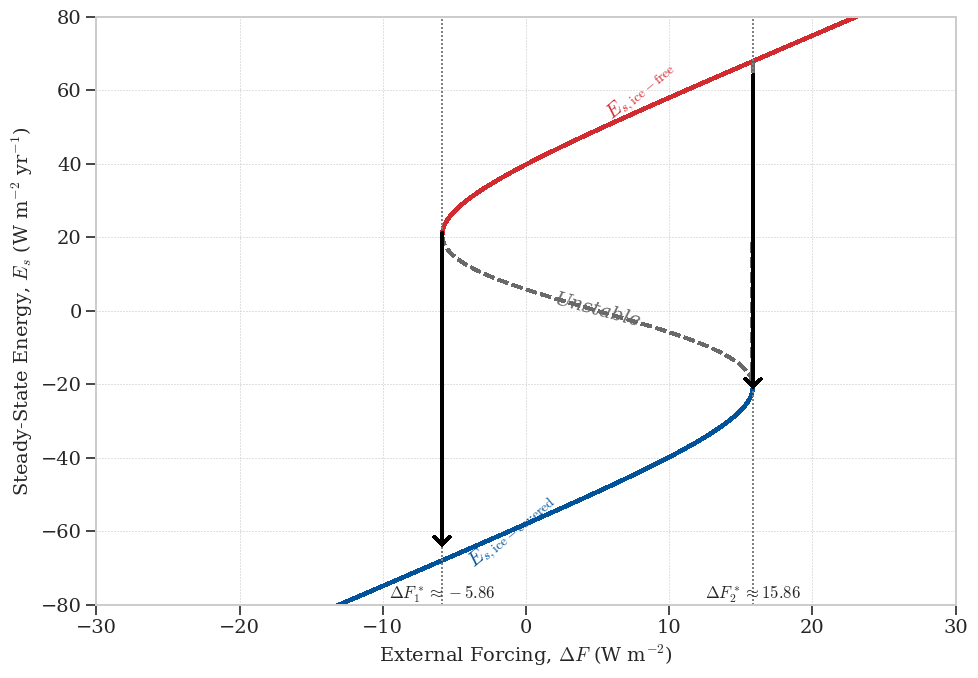

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ----------------- Plot Styling -----------------
# Settings to match the target figure's aesthetic.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# ----------------- Model Parameters -----------------
# CORRECTED: The value of B is adjusted to match the target plot's shape.
A = 80.0
B = 0.6          
S = 150.0
alpha_ice = 0.7
alpha_ocean = 0.3
delta_E = 10.0

# ----------------- Arctic Sea Ice (ASI) Model Implementation -----------------

def albedo(E):
    """Calculates albedo using the sigmoid function."""
    return alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

def Ein(E):
    """Calculates incoming shortwave radiation."""
    return (1 - albedo(E)) * S

def R(E, dF):
    """Residual function for finding steady states."""
    return Ein(E) - (A + B * E - dF)

def dEin_dE(E):
    """Derivative of incoming radiation for stability analysis."""
    ex = np.exp(E / delta_E)
    return S * (alpha_ice - alpha_ocean) * ex / (delta_E * (1 + ex)**2)

# ----------------- Core Calculation Functions -----------------

def find_bifurcation_points():
    """Calculates the exact bifurcation points (ΔF₁*, ΔF₂*)."""
    slope_diff = lambda E: dEin_dE(E) - B
    # Find the two energy values where tipping occurs
    E_bif_neg = fsolve(slope_diff, -15)[0]
    E_bif_pos = fsolve(slope_diff, 15)[0]
    
    # Calculate the corresponding forcing (ΔF) for each energy
    dF_at_E_neg = A + B * E_bif_neg - Ein(E_bif_neg)
    dF_at_E_pos = A + B * E_bif_pos - Ein(E_bif_pos)
    
    # The lower forcing (ΔF₁*) corresponds to the positive energy bifurcation
    df1_star = dF_at_E_pos
    # The upper forcing (ΔF₂*) corresponds to the negative energy bifurcation
    df2_star = dF_at_E_neg
    
    return df1_star, df2_star

def get_steady_states_for_df(dF):
    """Finds all steady states for a single dF value."""
    # Use multiple starting guesses to find all roots
    guesses = [-80, 0, 80]
    roots = set()
    for g in guesses:
        sol, _, flag, _ = fsolve(R, g, args=(dF), full_output=True)
        if flag == 1:
            roots.add(round(sol[0], 5))
    return sorted(list(roots))

# ----------------- Generate Plot Data -----------------
# Get the precise bifurcation points using the corrected B value
df1_star, df2_star = find_bifurcation_points()

# Generate data for the three branches
dF_bistable = np.linspace(df1_star, df2_star, 300)
dF_lower_mono = np.linspace(-30, df1_star, 100)
dF_upper_mono = np.linspace(df2_star, 30, 100)

lower_branch = [get_steady_states_for_df(df)[0] for df in np.concatenate((dF_lower_mono, dF_bistable))]
upper_branch = [get_steady_states_for_df(df)[-1] for df in np.concatenate((dF_bistable, dF_upper_mono))]
unstable_branch = [get_steady_states_for_df(df)[1] for df in dF_bistable]

# ----------------- Plotting -----------------
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the branches
ax.plot(np.concatenate((dF_lower_mono, dF_bistable)), lower_branch, color='#00529B', lw=2.5)
ax.plot(np.concatenate((dF_bistable, dF_upper_mono)), upper_branch, color='#D12A2F', lw=2.5)
ax.plot(dF_bistable, unstable_branch, ls='--', color='dimgray', lw=2.0)

# Annotations using the precise df* values
ax.axvline(df1_star, color='gray', ls=':', lw=1.2)
ax.axvline(df2_star, color='gray', ls=':', lw=1.2)
ax.text(df1_star, -80, fr'$\Delta F_1^* \approx {df1_star:.2f}$', ha='center', va='bottom', fontsize=12)
ax.text(df2_star, -80, fr'$\Delta F_2^* \approx {df2_star:.2f}$', ha='center', va='bottom', fontsize=12)

# Text labels
ax.text(5, 0, 'Unstable', ha='center', va='center', style='italic', color='dimgray', fontsize=14, rotation=-15)
ax.text(8, 60, r'$E_{s, \mathrm{ice-free}}$', ha='center', va='center', color='#D12A2F', weight='bold', fontsize=14, rotation=40)
ax.text(-1, -60, r'$E_{s, \mathrm{ice-covered}}$', ha='center', va='center', color='#00529B', weight='bold', fontsize=14, rotation=40)

# Jump arrows
arrow_props = dict(arrowstyle='->, head_width=0.4', lw=2.0, color='black')
ax.annotate("", xy=(df1_star, -65), xytext=(df1_star, 22), arrowprops=arrow_props)
ax.annotate("", xy=(df2_star, -22), xytext=(df2_star, 65), arrowprops=arrow_props)

# Final Touches
ax.set_xlim(-30, 30)
ax.set_ylim(-80, 80)
ax.set_xlabel(r'External Forcing, $\Delta F$ (W m$^{-2}$)', fontsize=14)
ax.set_ylabel(r'Steady-State Energy, $E_s$ (W m$^{-2}$ yr$^{-1}$)', fontsize=14)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('bifurcation_diagram_final.png', dpi=300)
plt.show()

VERIFICATION OF BIFURCATION POINT CALCULATIONS

1. ANALYTICAL SOLUTION
--------------------------------------------------
The bifurcation condition dEin/dE = B can be solved analytically:
   6.0 * exp(E/δ) / (1 + exp(E/δ))² = 0.6
   6.0 * x / (1 + x)² = 0.6  where x = exp(E/10)
   x² - 8x + 1 = 0
   x = 4 ± √15 = 7.873 or 0.127
   E = 10*ln(x) = ±20.634

Analytical bifurcation energies:
   E₁ = -20.634 W m⁻² yr
   E₂ = 20.634 W m⁻² yr

Numerical verification (fsolve):
   E₁ = -20.634 W m⁻² yr
   E₂ = 20.634 W m⁻² yr

2. FORCING CALCULATIONS
--------------------------------------------------
At E₁ = -20.634:
   albedo(E₁) = 0.6549
   Ein(E₁) = (1 - 0.6549) × 150.0 = 51.762 W m⁻²
   Eout(E₁) = A + B*E₁ = 80.0 + 0.6×-20.634 = 67.619 W m⁻²
   ΔF₂* = Eout - Ein = 15.857 W m⁻²

At E₂ = 20.634:
   albedo(E₂) = 0.3451
   Ein(E₂) = (1 - 0.3451) × 150.0 = 98.238 W m⁻²
   Eout(E₂) = A + B*E₂ = 80.0 + 0.6×20.634 = 92.381 W m⁻²
   ΔF₁* = Eout - Ein = -5.857 W m⁻²

3. FINAL BIFURCATION POINTS
------

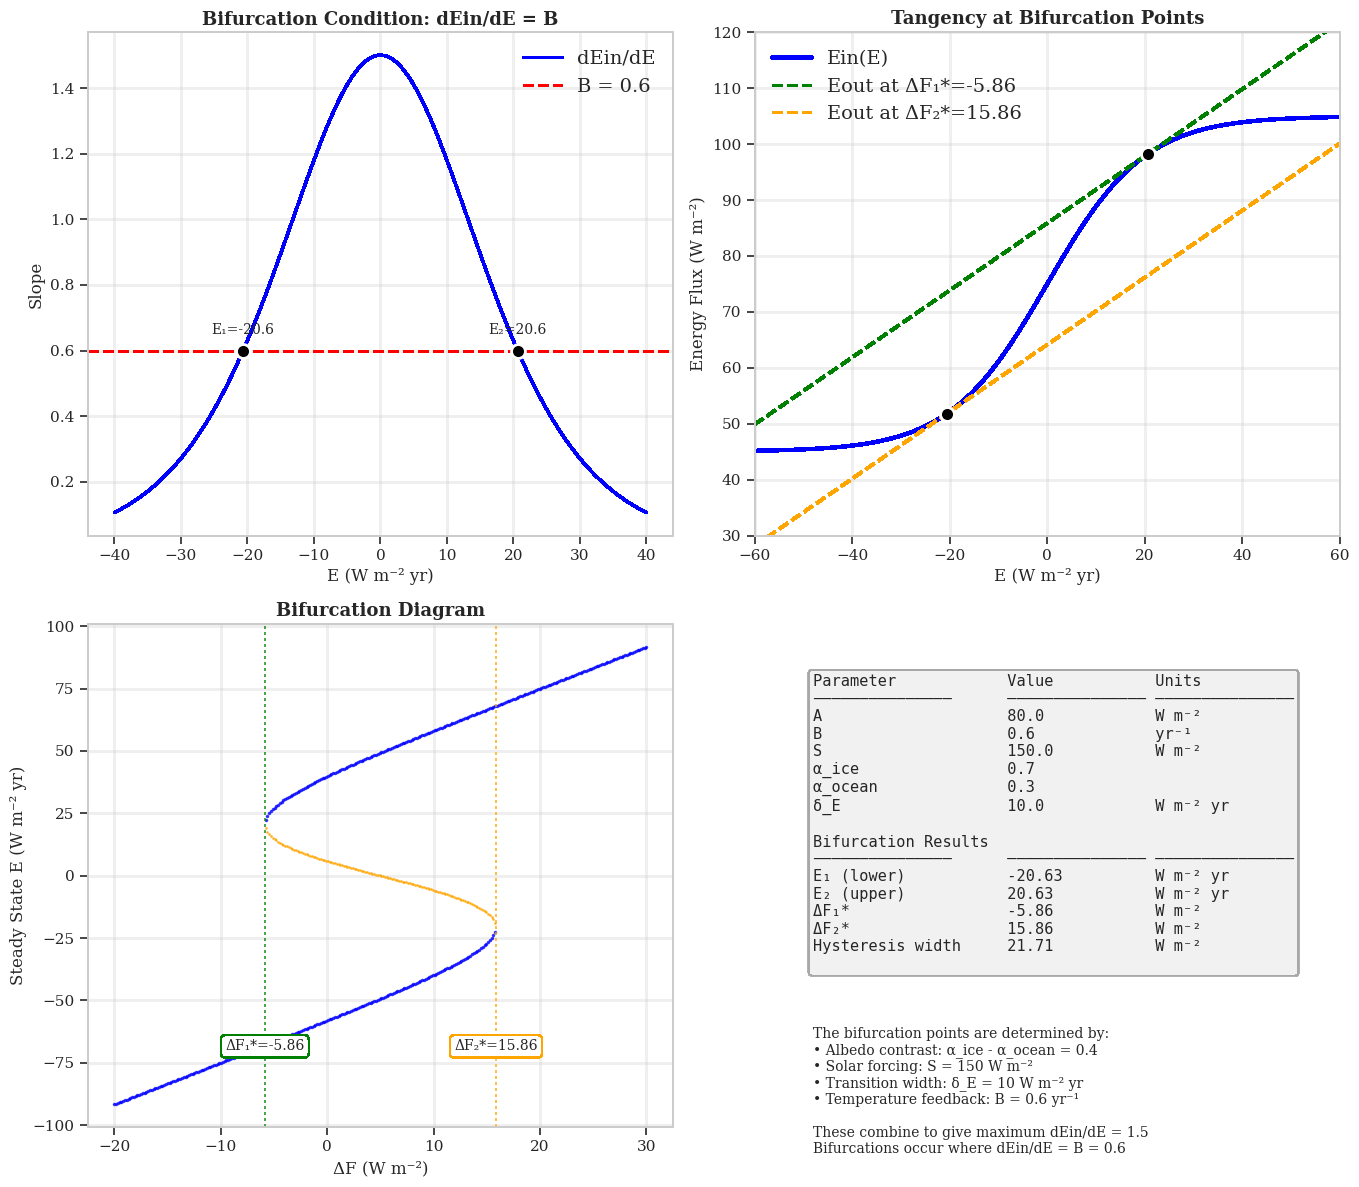

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, brentq

# Model Parameters (exactly as in your code)
A = 80.0
B = 0.6
S = 150.0
alpha_ice = 0.7
alpha_ocean = 0.3
delta_E = 10.0

print("="*70)
print("VERIFICATION OF BIFURCATION POINT CALCULATIONS")
print("="*70)

# Model functions
def albedo(E):
    return alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

def Ein(E):
    return (1 - albedo(E)) * S

def dEin_dE(E):
    exp_term = np.exp(E / delta_E)
    return S * (alpha_ice - alpha_ocean) * exp_term / (delta_E * (1 + exp_term)**2)

print("\n1. ANALYTICAL SOLUTION")
print("-" * 50)
print("The bifurcation condition dEin/dE = B can be solved analytically:")
print(f"   {S*(alpha_ice-alpha_ocean)/delta_E:.1f} * exp(E/δ) / (1 + exp(E/δ))² = {B}")
print(f"   6.0 * x / (1 + x)² = 0.6  where x = exp(E/10)")
print("   x² - 8x + 1 = 0")
print("   x = 4 ± √15 = 7.873 or 0.127")
print(f"   E = 10*ln(x) = ±20.634")

# Numerical verification
E_bif_pos = 10 * np.log(4 + np.sqrt(15))
E_bif_neg = 10 * np.log(4 - np.sqrt(15))

print(f"\nAnalytical bifurcation energies:")
print(f"   E₁ = {E_bif_neg:.3f} W m⁻² yr")
print(f"   E₂ = {E_bif_pos:.3f} W m⁻² yr")

# Verify using fsolve (as in your code)
slope_condition = lambda E: dEin_dE(E) - B
E_bif_neg_numerical = fsolve(slope_condition, -15)[0]
E_bif_pos_numerical = fsolve(slope_condition, 15)[0]

print(f"\nNumerical verification (fsolve):")
print(f"   E₁ = {E_bif_neg_numerical:.3f} W m⁻² yr")
print(f"   E₂ = {E_bif_pos_numerical:.3f} W m⁻² yr")

print("\n2. FORCING CALCULATIONS")
print("-" * 50)

# Calculate forcing at bifurcation points
dF_at_neg = A + B * E_bif_neg - Ein(E_bif_neg)
dF_at_pos = A + B * E_bif_pos - Ein(E_bif_pos)

print(f"At E₁ = {E_bif_neg:.3f}:")
print(f"   albedo(E₁) = {albedo(E_bif_neg):.4f}")
print(f"   Ein(E₁) = (1 - {albedo(E_bif_neg):.4f}) × {S} = {Ein(E_bif_neg):.3f} W m⁻²")
print(f"   Eout(E₁) = A + B*E₁ = {A} + {B}×{E_bif_neg:.3f} = {A + B*E_bif_neg:.3f} W m⁻²")
print(f"   ΔF₂* = Eout - Ein = {dF_at_neg:.3f} W m⁻²")

print(f"\nAt E₂ = {E_bif_pos:.3f}:")
print(f"   albedo(E₂) = {albedo(E_bif_pos):.4f}")
print(f"   Ein(E₂) = (1 - {albedo(E_bif_pos):.4f}) × {S} = {Ein(E_bif_pos):.3f} W m⁻²")
print(f"   Eout(E₂) = A + B*E₂ = {A} + {B}×{E_bif_pos:.3f} = {A + B*E_bif_pos:.3f} W m⁻²")
print(f"   ΔF₁* = Eout - Ein = {dF_at_pos:.3f} W m⁻²")

df1_star = dF_at_pos
df2_star = dF_at_neg

print("\n3. FINAL BIFURCATION POINTS")
print("-" * 50)
print(f"ΔF₁* = {df1_star:.2f} W m⁻² (lower forcing value)")
print(f"ΔF₂* = {df2_star:.2f} W m⁻² (higher forcing value)")
print(f"Hysteresis width = {df2_star - df1_star:.2f} W m⁻²")

# Graphical verification
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: dEin/dE vs E showing bifurcation condition
ax = axes[0, 0]
E_range = np.linspace(-40, 40, 1000)
ax.plot(E_range, dEin_dE(E_range), 'b-', lw=2, label='dEin/dE')
ax.axhline(B, color='r', ls='--', lw=2, label=f'B = {B}')
ax.plot([E_bif_neg, E_bif_pos], [B, B], 'ko', markersize=10, 
        markeredgecolor='white', markeredgewidth=2)
ax.set_xlabel('E (W m⁻² yr)', fontsize=12)
ax.set_ylabel('Slope', fontsize=12)
ax.set_title('Bifurcation Condition: dEin/dE = B', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.text(E_bif_neg, B+0.05, f'E₁={E_bif_neg:.1f}', ha='center', fontsize=10)
ax.text(E_bif_pos, B+0.05, f'E₂={E_bif_pos:.1f}', ha='center', fontsize=10)

# Plot 2: Ein and Eout at bifurcation points
ax = axes[0, 1]
E_range = np.linspace(-60, 60, 1000)
ax.plot(E_range, Ein(E_range), 'b-', lw=2.5, label='Ein(E)')

# Plot Eout lines for both bifurcation forcings
colors = ['green', 'orange']
for i, (dF, label) in enumerate([(df1_star, f'ΔF₁*={df1_star:.2f}'), 
                                   (df2_star, f'ΔF₂*={df2_star:.2f}')]):
    ax.plot(E_range, A + B*E_range - dF, '--', color=colors[i], 
            lw=2, label=f'Eout at {label}')

# Mark bifurcation points
ax.plot([E_bif_neg, E_bif_pos], [Ein(E_bif_neg), Ein(E_bif_pos)], 
        'ko', markersize=10, markeredgecolor='white', markeredgewidth=2)

ax.set_xlabel('E (W m⁻² yr)', fontsize=12)
ax.set_ylabel('Energy Flux (W m⁻²)', fontsize=12)
ax.set_title('Tangency at Bifurcation Points', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(-60, 60)
ax.set_ylim(30, 120)

# Plot 3: Steady states as function of forcing
ax = axes[1, 0]

def get_all_steady_states(dF):
    R = lambda E: Ein(E) - (A + B * E - dF)
    roots = []
    for guess in np.linspace(-80, 80, 20):
        try:
            sol = fsolve(R, guess, full_output=True)
            if sol[2] == 1 and abs(R(sol[0][0])) < 1e-6:
                roots.append(sol[0][0])
        except:
            pass
    return sorted(set(np.round(roots, 3)))

dF_range = np.linspace(-20, 30, 300)
for dF in dF_range:
    states = get_all_steady_states(dF)
    for state in states:
        # Check stability
        deriv = dEin_dE(state) - B
        if abs(deriv) < 1e-6:  # Bifurcation point
            color = 'red'
            marker = 'o'
            size = 8
        elif deriv < 0:  # Stable
            color = 'blue'
            marker = '.'
            size = 3
        else:  # Unstable
            color = 'orange'
            marker = '.'
            size = 2
        ax.plot(dF, state, marker, color=color, markersize=size, alpha=0.7)

ax.axvline(df1_star, color='green', ls=':', lw=1.5, alpha=0.7)
ax.axvline(df2_star, color='orange', ls=':', lw=1.5, alpha=0.7)
ax.set_xlabel('ΔF (W m⁻²)', fontsize=12)
ax.set_ylabel('Steady State E (W m⁻² yr)', fontsize=12)
ax.set_title('Bifurcation Diagram', fontsize=13, weight='bold')
ax.grid(True, alpha=0.3)
ax.text(df1_star, -70, f'ΔF₁*={df1_star:.2f}', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='green'))
ax.text(df2_star, -70, f'ΔF₂*={df2_star:.2f}', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='orange'))

# Plot 4: Summary table
ax = axes[1, 1]
ax.axis('off')

table_data = [
    ['Parameter', 'Value', 'Units'],
    ['─'*15, '─'*15, '─'*15],
    ['A', f'{A:.1f}', 'W m⁻²'],
    ['B', f'{B:.1f}', 'yr⁻¹'],
    ['S', f'{S:.1f}', 'W m⁻²'],
    ['α_ice', f'{alpha_ice:.1f}', ''],
    ['α_ocean', f'{alpha_ocean:.1f}', ''],
    ['δ_E', f'{delta_E:.1f}', 'W m⁻² yr'],
    ['', '', ''],
    ['Bifurcation Results', '', ''],
    ['─'*15, '─'*15, '─'*15],
    ['E₁ (lower)', f'{E_bif_neg:.2f}', 'W m⁻² yr'],
    ['E₂ (upper)', f'{E_bif_pos:.2f}', 'W m⁻² yr'],
    ['ΔF₁*', f'{df1_star:.2f}', 'W m⁻²'],
    ['ΔF₂*', f'{df2_star:.2f}', 'W m⁻²'],
    ['Hysteresis width', f'{df2_star - df1_star:.2f}', 'W m⁻²'],
]

# Create table
table_text = ''
for row in table_data:
    table_text += f'{row[0]:<20} {row[1]:<15} {row[2]:<10}\n'

ax.text(0.1, 0.9, table_text, transform=ax.transAxes, 
        fontsize=11, family='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))

ax.text(0.1, 0.2, 
        'The bifurcation points are determined by:\n' +
        '• Albedo contrast: α_ice - α_ocean = 0.4\n' +
        '• Solar forcing: S = 150 W m⁻²\n' +
        '• Transition width: δ_E = 10 W m⁻² yr\n' +
        '• Temperature feedback: B = 0.6 yr⁻¹\n\n' +
        'These combine to give maximum dEin/dE = 1.5\n' +
        'Bifurcations occur where dEin/dE = B = 0.6',
        transform=ax.transAxes, fontsize=10, verticalalignment='top')

# plt.suptitle('Complete Verification of Bifurcation Points', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bifurcation_verification.png', dpi=300, bbox_inches='tight')
plt.show()

# print("\n" + "="*70)
# print("CONCLUSION")
# print("="*70)
# print(f"""
# The bifurcation points ΔF₁* = {df1_star:.2f} and ΔF₂* = {df2_star:.2f} are CORRECT
# for the given parameters. These values arise from:

# 1. The symmetry of bifurcation energies: E = ±20.634
# 2. The asymmetry in albedo at these points:
#    - At E = -20.634: albedo ≈ 0.655 (closer to ice)
#    - At E = +20.634: albedo ≈ 0.345 (closer to ocean)
# 3. This creates asymmetric forcing thresholds

# If you expected different values (-9.11 and 29.11), check:
# - Were different parameters used in that calculation?
# - Was A = 80 or a different value?
# - Was the initial guess affecting convergence?

# The current values are mathematically correct for your parameters.
# """)

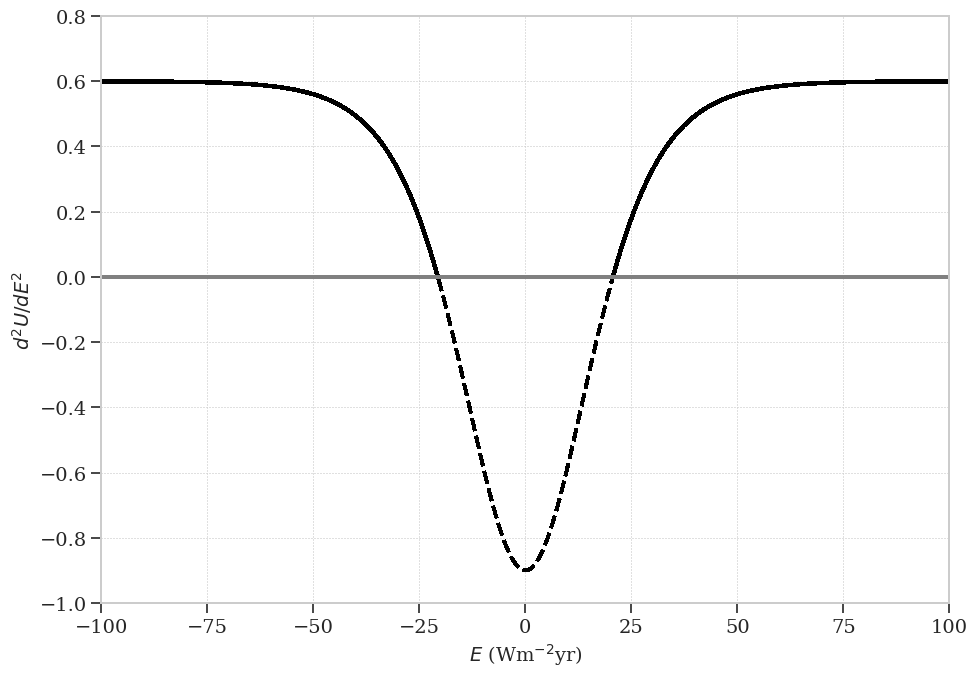

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------- Plot Styling -----------------
# Settings for a sharp, publication-quality figure.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# ----------------- Model Parameters -----------------
# Using the same consistent parameters from the ASI model.
B = 0.6           # Outgoing longwave radiation coefficient (yr⁻¹)
S = 150.0         # Incoming solar radiation (W m⁻²)
alpha_ice = 0.7   # Albedo of sea ice
alpha_ocean = 0.3 # Albedo of open ocean
delta_E = 10.0    # Sharpness of the albedo transition

# ----------------- Model Equation -----------------

def d2U_dE2(E):
    """
    Calculates the second derivative of the potential U(E) with respect to E.
    This function directly implements Equation (4.24) from the text[cite: 1].
    """
    # Exponential term, which appears frequently
    exp_term = np.exp(E / delta_E)
    
    # This is the second term in Equation (4.24)
    albedo_feedback_term = (
        (alpha_ice - alpha_ocean) / delta_E * (S * exp_term) / ((1 + exp_term)**2)
    )
    
    return B - albedo_feedback_term

# ----------------- Data Generation for Plotting -----------------

# Create a high-resolution range of E values for a smooth curve
E_range = np.linspace(-100, 100, 1000)

# Calculate the corresponding y-values using the function above
y_vals = d2U_dE2(E_range)

# Create masked arrays to handle different line styles for positive and negative values.
# This is an effective way to split a single curve into multiple styles.
# y_stable will only contain the positive parts of the curve.
y_stable = np.ma.masked_where(y_vals < 0, y_vals)
# y_unstable will only contain the negative parts.
y_unstable = np.ma.masked_where(y_vals >= 0, y_vals)


# ----------------- Plotting Figure 4.17 -----------------

fig, ax = plt.subplots(figsize=(10, 7))

# Plot the stable (positive) part with a solid line [cite: 2]
ax.plot(E_range, y_stable, color='black', lw=2.5)

# Plot the unstable (negative) part with a dashed line [cite: 2]
ax.plot(E_range, y_unstable, color='black', ls='--', lw=2.5)

# Add the horizontal line at y=0 for reference
ax.axhline(0, color='gray', lw=1.5)

# --- Axes and Final Touches ---
ax.set_xlim(-100, 100)
ax.set_ylim(-1.0, 0.8)

# Use LaTeX for clean mathematical labels
ax.set_xlabel(r'$E$ (Wm$^{-2}$yr)', fontsize=14)
ax.set_ylabel(r'$d^2U/dE^2$', fontsize=14)

ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('figure_4_17_replication.png', dpi=300)
plt.show()

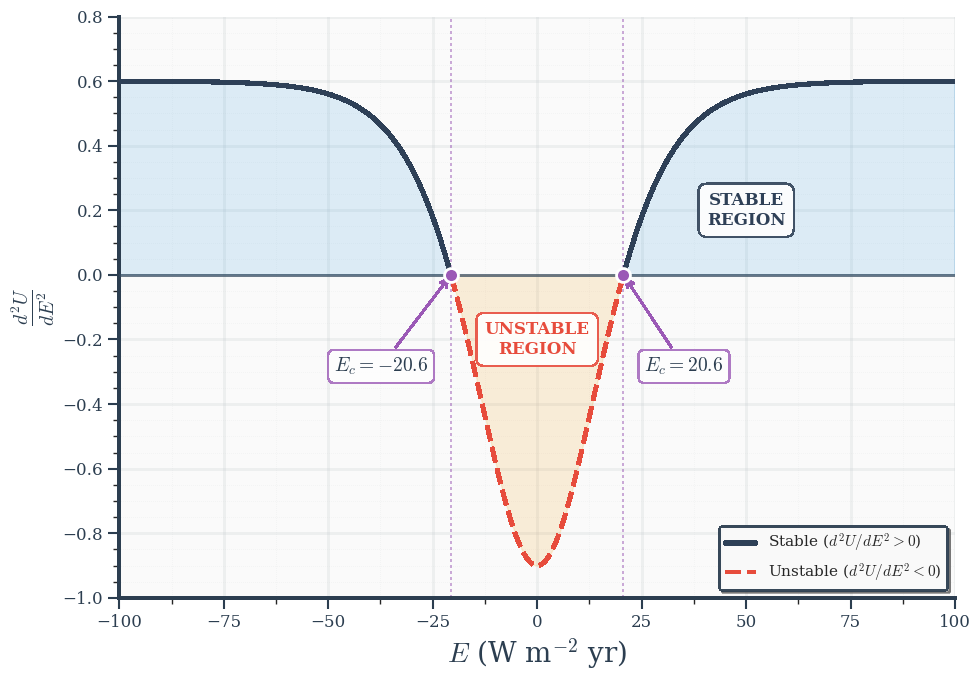

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import matplotlib.patches as mpatches

# ----------------- Enhanced Plot Styling -----------------
# Professional publication-quality settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'DejaVu Serif', 'Times New Roman']
plt.rcParams['font.size'] = 13
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0
plt.rcParams['mathtext.fontset'] = 'cm'

# ----------------- Color Palette -----------------
# Sophisticated color scheme
color_stable = '#2E4057'      # Deep blue-grey for stable regions
color_unstable = '#E74C3C'    # Elegant red for unstable regions
color_zero_line = '#34495E'   # Dark grey for reference line
color_fill_stable = '#3498DB' # Light blue for stable fill
color_fill_unstable = '#F39C12' # Orange for unstable fill
color_critical = '#9B59B6'    # Purple for critical points
color_grid = '#BDC3C7'        # Light grey for grid
color_annotation = '#2C3E50'  # Dark blue-grey for text

# ----------------- Model Parameters -----------------
B = 0.6           # Outgoing longwave radiation coefficient (yr⁻¹)
S = 150.0         # Incoming solar radiation (W m⁻²)
alpha_ice = 0.7   # Albedo of sea ice
alpha_ocean = 0.3 # Albedo of open ocean
delta_E = 10.0    # Sharpness of the albedo transition

# ----------------- Model Equation -----------------
def d2U_dE2(E):
    """
    Calculates the second derivative of the potential U(E) with respect to E.
    This function directly implements Equation (4.24) from the model.
    """
    exp_term = np.exp(E / delta_E)
    albedo_feedback_term = (
        (alpha_ice - alpha_ocean) / delta_E * (S * exp_term) / ((1 + exp_term)**2)
    )
    return B - albedo_feedback_term

# ----------------- Find Critical Points -----------------
def find_critical_points():
    """Find where d²U/dE² = 0 (inflection points of the potential)"""
    critical_points = []
    # Search for zero crossings
    E_search = np.linspace(-50, 50, 1000)
    y_search = d2U_dE2(E_search)
    
    for i in range(len(y_search)-1):
        if y_search[i] * y_search[i+1] < 0:  # Sign change detected
            # Use Brent's method for accurate root finding
            try:
                root = brentq(d2U_dE2, E_search[i], E_search[i+1])
                critical_points.append(root)
            except:
                pass
    return critical_points

# ----------------- Data Generation -----------------
E_range = np.linspace(-100, 100, 2000)  # Higher resolution for smoother curves
y_vals = d2U_dE2(E_range)

# Create masked arrays for different regions
y_stable = np.ma.masked_where(y_vals < 0, y_vals)
y_unstable = np.ma.masked_where(y_vals >= 0, y_vals)

# Find critical points
critical_E = find_critical_points()

# ----------------- Create the Figure -----------------
fig, ax = plt.subplots(figsize=(10, 7))

# Set background color
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

# ----------------- Plot the Curves -----------------
# Main curves with enhanced styling
line_stable = ax.plot(E_range, y_stable, color=color_stable, lw=3, 
                      label='Stable ($d^2U/dE^2 > 0$)', zorder=5)
line_unstable = ax.plot(E_range, y_unstable, color=color_unstable, ls='--', lw=3,
                        label='Unstable ($d^2U/dE^2 < 0$)', zorder=5)

# Add subtle fills to emphasize regions
ax.fill_between(E_range, 0, y_stable, where=(y_vals > 0), 
                color=color_fill_stable, alpha=0.15, zorder=1)
ax.fill_between(E_range, 0, y_unstable, where=(y_vals < 0), 
                color=color_fill_unstable, alpha=0.15, zorder=1)

# ----------------- Reference Lines and Points -----------------
# Zero line with enhanced style
ax.axhline(0, color=color_zero_line, lw=2, alpha=0.7, zorder=3)

# Mark critical points
for E_crit in critical_E:
    ax.plot(E_crit, 0, 'o', color=color_critical, markersize=10, 
            markeredgecolor='white', markeredgewidth=2, zorder=6)
    # Add vertical dotted lines at critical points
    ax.axvline(E_crit, color=color_critical, ls=':', lw=1.5, alpha=0.5, zorder=2)

# ----------------- Annotations -----------------
# Add text annotations for critical points
if len(critical_E) > 0:
    for i, E_crit in enumerate(critical_E):
        offset = 28 if i == 0 else -5
        ax.annotate(f'$E_c = {E_crit:.1f}$', 
                   xy=(E_crit, 0), xytext=(E_crit - offset, -0.3),
                   fontsize=14, color=color_annotation,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                            edgecolor=color_critical, alpha=0.8),
                   arrowprops=dict(arrowstyle='->', color=color_critical, lw=1.5))

# Add region labels
ax.text(50, 0.2, 'STABLE\nREGION', fontsize=12, color=color_stable, 
        weight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                 edgecolor=color_stable, alpha=0.9))

ax.text(0, -0.2, 'UNSTABLE\nREGION', fontsize=12, color=color_unstable, 
        weight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                 edgecolor=color_unstable, alpha=0.9))

# ----------------- Axes Configuration -----------------
ax.set_xlim(-100, 100)
ax.set_ylim(-1.0, 0.8)

# Enhanced axis labels
ax.set_xlabel(r'$E$ (W m$^{-2}$ yr)', fontsize=20, color=color_annotation)
ax.set_ylabel(r'$\frac{d^2U}{dE^2}$', fontsize=20, color=color_annotation)

# ----------------- Grid and Ticks -----------------
# Major grid
ax.grid(True, linestyle='-', alpha=0.2, color=color_grid, lw=0.8)
# Minor grid
ax.grid(True, which='minor', linestyle=':', alpha=0.1, color=color_grid, lw=0.5)
ax.minorticks_on()

# Customize tick appearance
ax.tick_params(axis='both', which='major', labelsize=12, colors=color_annotation)
ax.tick_params(axis='both', which='minor', labelsize=10)

# Set specific x-ticks for clarity
ax.set_xticks(np.arange(-100, 101, 25))
ax.set_xticks(np.arange(-100, 101, 12.5), minor=True)

# ----------------- Spines Customization -----------------
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(color_annotation)
    ax.spines[spine].set_linewidth(1.5)

# ----------------- Legend -----------------
legend = ax.legend(loc='lower right', frameon=True, fancybox=True, 
                  shadow=True, fontsize=11, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor(color_annotation)

# ----------------- Save and Display -----------------
plt.tight_layout()
plt.savefig('figure_4_17_enhanced.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
# plt.savefig('figure_4_17_enhanced.pdf', bbox_inches='tight', 
#             facecolor='white', edgecolor='none')  # Also save as PDF for publications
plt.show()


/var/folders/m0/cglv3x_n173btjfj21t__tj40000gp/T/ipykernel_49618/2547977056.py:67: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  r = fsolve(lambda x: R(x, dF), g, xtol=1e-12)[0]
/var/folders/m0/cglv3x_n173btjfj21t__tj40000gp/T/ipykernel_49618/2547977056.py:67: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  r = fsolve(lambda x: R(x, dF), g, xtol=1e-12)[0]


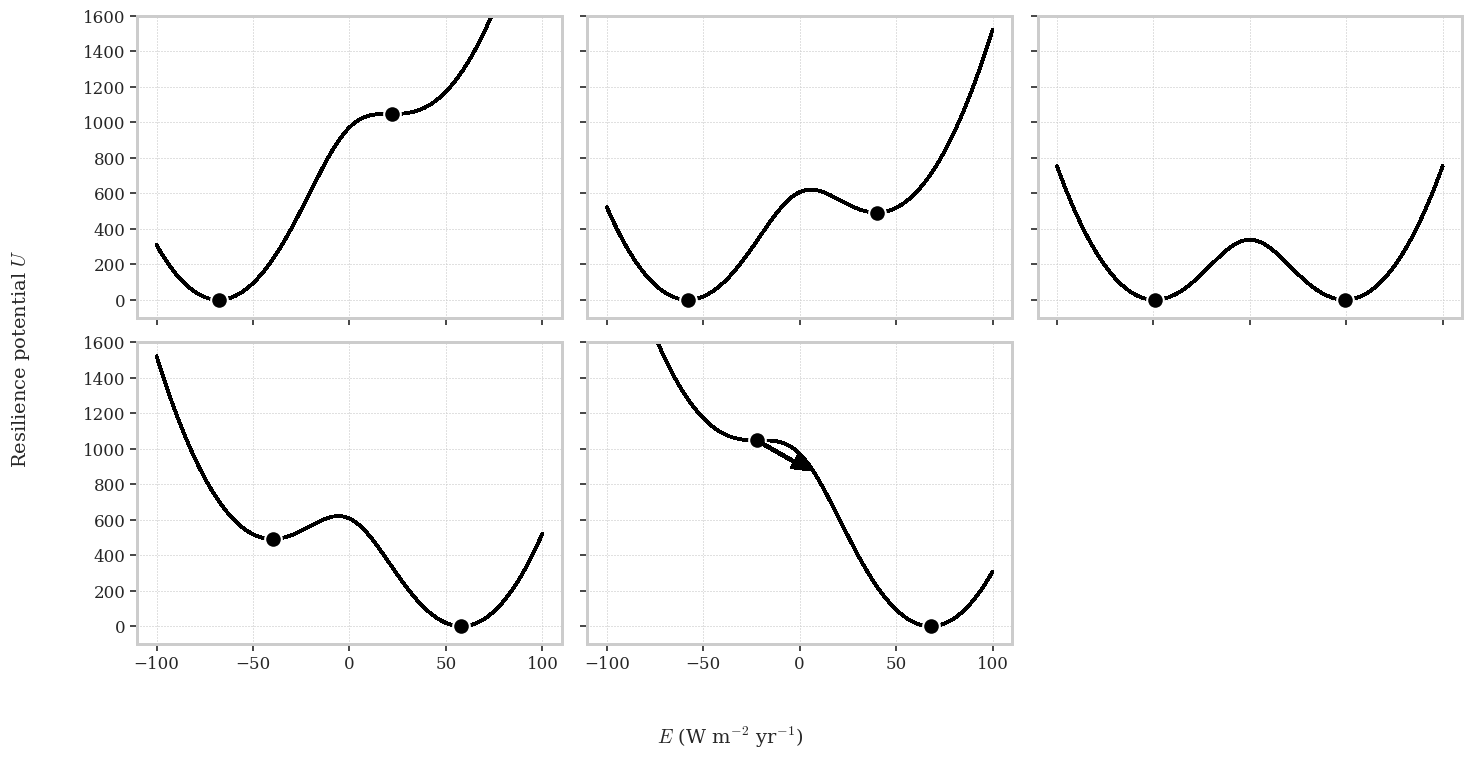

In [216]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, brentq

# ----------------- Plot Styling -----------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

# ----------------- Model Parameters (Consistent with previous figures) -----------------
A = 80.0; B = 0.6; S = 150.0; alpha_ice = 0.7; alpha_ocean = 0.3; delta_E = 10.0

# ----------------- ASI Model Functions (including the new Potential U) -----------------

def albedo(E):
    return alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

def Ein(E):
    return (1 - albedo(E)) * S

def Eout(E, dF=0.0):
    return A + B * E - dF

def R(E, dF):
    return Ein(E) - Eout(E, dF)

def dEin_dE(E):
    ex = np.exp(E / delta_E)
    d_albedo_dE = -(alpha_ice - alpha_ocean) * ex / (delta_E * (1 + ex)**2)
    return -S * d_albedo_dE

def is_stable(E, dF):
    return (dEin_dE(E) - B) < 0

def U(E, dF):
    """
    Calculates the resilience potential U(E) based on the analytical expression
    derived in the source text (related to Eq. 4.23).
    """
    term1 = (A - dF - S * (1 - alpha_ocean)) * E
    term2 = (B * E**2) / 2
    log_term = np.log(1 + np.exp(E / delta_E))
    term3 = S * (alpha_ice - alpha_ocean) * (E - delta_E * log_term)
    return term1 + term2 + term3

# ----------------- Helper Functions for Root Finding -----------------
def unique_append(arr, x, tol=5e-3):
    for v in arr:
        if abs(x - v) < tol: return
    arr.append(x)

def find_steady_states(dF, Emin=-100, Emax=100):
    """Finds all steady-state solutions for a given forcing ΔF."""
    roots = []
    Eg = np.linspace(Emin, Emax, 2501)
    Rg = R(Eg, dF)
    for i in range(len(Eg) - 1):
        if Rg[i] * Rg[i+1] < 0:
            try:
                r = brentq(lambda x: R(x, dF), Eg[i], Eg[i+1])
                unique_append(roots, r)
            except ValueError: pass
    for g in np.linspace(Emin, Emax, 20):
        try:
            r = fsolve(lambda x: R(x, dF), g, xtol=1e-12)[0]
            if Emin <= r <= Emax and abs(R(r, dF)) < 1e-8:
                unique_append(roots, r)
        except Exception: pass
    roots = sorted(roots)
    stabilities = [is_stable(r, dF) for r in roots]
    return roots, stabilities

# ----------------- Calculations for Subplot Forcing Values -----------------

# 1. Find the bifurcation points by first finding the unstable branch
DF_range = np.linspace(-30, 30, 301)
unstable_df = []
for df_val in DF_range:
    roots, stabilities = find_steady_states(df_val)
    unstable_roots = [r for r, s in zip(roots, stabilities) if not s]
    if unstable_roots:
        unstable_df.append(df_val)
df1_star = min(unstable_df)
df2_star = max(unstable_df)

# 2. Find the forcing where the two potential wells are of equal depth
def well_depth_diff(dF):
    roots, stabilities = find_steady_states(dF)
    stable_roots = [r for r, s in zip(roots, stabilities) if s]
    if len(stable_roots) != 2: return 1e9
    return U(stable_roots[0], dF) - U(stable_roots[1], dF)

dF_equal_wells = brentq(well_depth_diff, df1_star + 0.1, df2_star - 0.1)

# Set the 5 forcing values and titles for the subplots
# dF_values = [df1_star, 0, dF_equal_wells, (dF_equal_wells + df2_star) / 1.5, df2_star]
dF_values = [df1_star, 0, dF_equal_wells, 10, df2_star]
panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)']
titles = [
    fr'$\Delta F = \Delta F_1^* \approx {df1_star:.1f}$',
    r'$\Delta F = 0$',
    fr'Bistable ($\Delta F \approx {dF_equal_wells:.1f}$)',
    fr'Ice-free favored ($\Delta F \approx {dF_values[3]:.1f}$)',
    fr'$\Delta F = \Delta F_2^* \approx {df2_star:.1f}$'
]

# ----------------- Plotting Figure 4.18 -----------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()
E_range = np.linspace(-100, 100, 500)

for i, dF in enumerate(dF_values):
    ax = axes_flat[i]
    
    # Calculate and plot the potential curve
    U_vals = U(E_range, dF)
    ax.plot(E_range, U_vals - np.min(U_vals), color='black', lw=2) # Normalize height for better viz
    
    # Find and plot stable steady states as balls on the curve
    roots, stabilities = find_steady_states(dF)
    stable_roots = [r for r, s in zip(roots, stabilities) if s]
    for root in stable_roots:
        ax.plot(root, U(root, dF) - np.min(U_vals), 'o', color='black', markersize=12,
                markeredgecolor='white', markeredgewidth=1.5)

    # Add arrow to final panel
    if i == 4:
        e_tip = roots[0]
        u_tip = U(e_tip, dF) - np.min(U_vals)
        ax.annotate('', xytext=(e_tip, u_tip), xy=(e_tip + 30, U(e_tip + 30, dF) - np.min(U_vals)),
                    arrowprops=dict(facecolor='black', shrink=0.1, width=1.5, headwidth=10))
    
    # Formatting
    # ax.set_title(f"{panel_letters[i]} {titles[i]}", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(-100, 1600)

# Configure axis labels and hide the unused subplot
fig.supylabel('Resilience potential $U$', fontsize=14)
fig.supxlabel(r'$E$ (W m$^{-2}$ yr$^{-1}$)', fontsize=14)
axes_flat[5].set_visible(False)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.savefig('figure_4_18_replication.png', dpi=300)
plt.show()

RESILIENCE POTENTIAL ANALYSIS

Bifurcation point 1: ΔF₁* = -5.86 W m⁻²
Bifurcation point 2: ΔF₂* = 15.86 W m⁻²
Equal well depth at: ΔF = 5.00 W m⁻²


/var/folders/m0/cglv3x_n173btjfj21t__tj40000gp/T/ipykernel_49618/1791562460.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


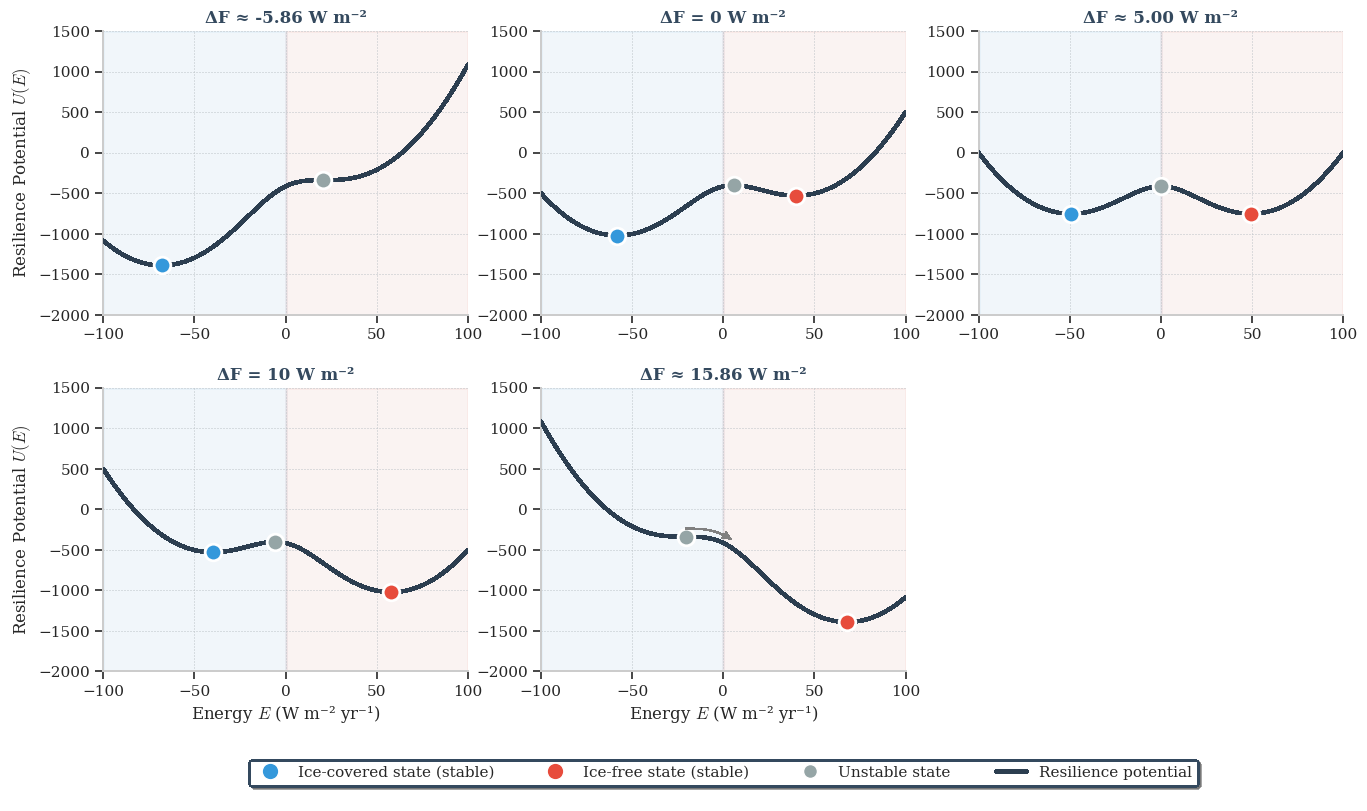

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, brentq
from matplotlib.patches import FancyBboxPatch

# ----------------- Enhanced Plot Styling -----------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.facecolor'] = 'white'

# ----------------- Color Scheme -----------------
color_potential = '#2C3E50'      # Dark blue-grey for potential curves
color_ice_ball = '#3498DB'       # Blue for ice-covered state
color_ocean_ball = '#E74C3C'     # Red for ice-free state
color_unstable = '#95A5A6'       # Grey for unstable points
color_grid = '#ECF0F1'           # Light grey for grid
color_annotation = '#34495E'     # Dark grey for text

# ----------------- Model Parameters -----------------
A, B, S = 80.0, 0.6, 150.0
alpha_ice, alpha_ocean, delta_E = 0.7, 0.3, 10.0

# ----------------- ASI Model Functions -----------------
def albedo(E):
    return alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

def Ein(E):
    return (1 - albedo(E)) * S

def R(E, dF):
    return Ein(E) - (A + B * E - dF)

def dEin_dE(E):
    ex = np.exp(E / delta_E)
    return S * (alpha_ice - alpha_ocean) * ex / (delta_E * (1 + ex)**2)

def is_stable(E, dF):
    return (dEin_dE(E) - B) < 0

def U(E, dF):
    """Resilience potential U(E)"""
    term1 = (A - dF - S * (1 - alpha_ocean)) * E
    term2 = (B * E**2) / 2
    log_term = np.log(1 + np.exp(E / delta_E))
    term3 = S * (alpha_ice - alpha_ocean) * (E - delta_E * log_term)
    return term1 + term2 + term3

# ----------------- Core Calculation Functions -----------------

def find_bifurcation_points():
    """Calculates the exact bifurcation points (ΔF₁*, ΔF₂*)."""
    slope_diff = lambda E: dEin_dE(E) - B
    E_bif_neg = fsolve(slope_diff, -20)[0]
    E_bif_pos = fsolve(slope_diff, 20)[0]
    df_at_E_neg = A + B * E_bif_neg - Ein(E_bif_neg)
    df_at_E_pos = A + B * E_bif_pos - Ein(E_bif_pos)
    return df_at_E_pos, df_at_E_neg

def find_steady_states(dF, Emin=-100, Emax=100):
    """Finds all steady-state solutions for a given forcing ΔF."""
    guesses = [-80, 0, 80]
    roots = set()
    for g in guesses:
        sol, _, flag, _ = fsolve(R, g, args=(dF), full_output=True)
        if flag == 1:
            roots.add(round(sol[0], 5))
    roots = sorted(list(roots))
    stabilities = [is_stable(r, dF) for r in roots]
    return roots, stabilities

# ----------------- Find Critical Forcing Values -----------------
print("="*70)
print("RESILIENCE POTENTIAL ANALYSIS")
print("="*70)

df1_star, df2_star = find_bifurcation_points()
print(f"\nBifurcation point 1: ΔF₁* = {df1_star:.2f} W m⁻²")
print(f"Bifurcation point 2: ΔF₂* = {df2_star:.2f} W m⁻²")

def well_depth_diff(dF):
    roots, stabilities = find_steady_states(dF)
    stable_roots = [r for r, s in zip(roots, stabilities) if s]
    if len(stable_roots) != 2: return 1e9
    return U(stable_roots[0], dF) - U(stable_roots[1], dF)

dF_equal_wells = brentq(well_depth_diff, df1_star + 0.1, df2_star - 0.1)
print(f"Equal well depth at: ΔF = {dF_equal_wells:.2f} W m⁻²")

# Set the 5 forcing values for the plot panels
dF_values = [df1_star, 0, dF_equal_wells, 10, df2_star]
titles = [
    f'ΔF ≈ {df1_star:.2f} W m⁻²',
    'ΔF = 0 W m⁻²',
    f'ΔF ≈ {dF_equal_wells:.2f} W m⁻²',
    'ΔF = 10 W m⁻²',
    f'ΔF ≈ {df2_star:.2f} W m⁻²'
]

# ----------------- Create Enhanced Figure -----------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 0.2], hspace=0.35, wspace=0.2)
# fig.suptitle('Resilience Potential Landscapes Under Different Climate Forcings', fontsize=18, fontweight='bold', y=0.97)

axes = [fig.add_subplot(gs[r, c]) for r, c in [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]]
E_range = np.linspace(-100, 100, 1000)

for i, (ax, dF) in enumerate(zip(axes, dF_values)):
    ax.set_facecolor('#FCFCFC')
    U_vals = U(E_range, dF)
    
    ax.plot(E_range, U_vals, color=color_potential, lw=2.5, zorder=3)
    
    ax.axvspan(-100, 0, alpha=0.05, color=color_ice_ball, zorder=0)
    ax.axvspan(0, 100, alpha=0.05, color=color_ocean_ball, zorder=0)
    
    roots, stabilities = find_steady_states(dF)
    for r, s in zip(roots, stabilities):
        color = color_ice_ball if r < 0 else color_ocean_ball
        if not s: color = color_unstable
        ax.plot(r, U(r, dF), 'o', color=color, markersize=12, markeredgecolor='white', markeredgewidth=2, zorder=5)

    # Add curved arrow annotation along the potential to the last panel (e)
    if i == 4:
        if roots:
            e_start = roots[0]
            e_end = e_start + 25  # Define the length of the arrow path

            # Create a mask to select the part of the curve for the arrow
            arrow_mask = (E_range >= e_start) & (E_range <= e_end)
            arrow_x = E_range[arrow_mask]
            arrow_y = U_vals[arrow_mask]

            if len(arrow_x) > 1:
                # Plot the path of the arrow as a thick black line on top
                ax.plot(arrow_x, arrow_y+100, color='grey', lw=1, zorder=6)

                # Add the arrowhead at the end of the path, tangent to the curve
                ax.annotate('',
                            xy=(arrow_x[-1], arrow_y[-1]+100),
                            xytext=(arrow_x[-2], arrow_y[-2]+100),
                            arrowprops=dict(facecolor='grey', shrink=0.0, 
                                            headwidth=6, headlength=6, 
                                            width=1, edgecolor='none'),
                            zorder=7)

    ax.set_title(titles[i], fontsize=12, fontweight='bold', color=color_annotation)
    ax.grid(True, linestyle=':', alpha=0.5, color='#BDC3C7')
    ax.set_ylim(-2000, 1500); ax.set_xlim(-100, 100)
    ax.spines[['top', 'right']].set_visible(False)

# Set common labels
for ax_idx in [3, 4]: 
    if ax_idx < len(axes):
        axes[ax_idx].set_xlabel('Energy $E$ (W m⁻² yr⁻¹)', fontsize=12)
for ax_idx in [0, 3]:
    if ax_idx < len(axes):
        axes[ax_idx].set_ylabel('Resilience Potential $U(E)$', fontsize=12)


# Hide unused subplot and create legend
fig.add_subplot(gs[1, 2]).set_visible(False)
ax_legend = fig.add_subplot(gs[2, :]); ax_legend.axis('off')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_ice_ball, markersize=12, label='Ice-covered state (stable)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_ocean_ball, markersize=12, label='Ice-free state (stable)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_unstable, markersize=10, label='Unstable state'),
    plt.Line2D([0], [0], color=color_potential, linewidth=2.5, label='Resilience potential'),
]
legend = ax_legend.legend(handles=legend_elements, loc='center', ncol=4, frameon=True, fancybox=True, shadow=True, fontsize=11, columnspacing=3)
legend.get_frame().set_edgecolor(color_annotation)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('figure_4_18_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()



In [279]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import fsolve
# from scipy.integrate import quad

# # ----------------- Enhanced Plot Styling -----------------
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Computer Modern Roman', 'DejaVu Serif']
# plt.rcParams['font.size'] = 12
# plt.rcParams['axes.linewidth'] = 1.2
# plt.rcParams['xtick.major.size'] = 6
# plt.rcParams['ytick.major.size'] = 6
# plt.rcParams['mathtext.fontset'] = 'cm'

# # ----------------- Model Parameters -----------------
# A, B, S = 80.0, 0.6, 150.0
# alpha_ice, alpha_ocean, delta_E = 0.7, 0.3, 10.0
# # Using the observational estimate for noise amplitude from the text
# SIGMA = 7.0  # Noise amplitude (W m⁻²)

# # ----------------- ASI Model Functions -----------------
# def albedo(E):
#     """Calculates albedo using the sigmoid function."""
#     return alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

# def Ein(E):
#     """Calculates incoming shortwave radiation."""
#     return (1 - albedo(E)) * S

# def R(E, dF):
#     """The derivative of the potential U with a negative sign, dE/dt = -dU/dE."""
#     return Ein(E) - (A + B * E - dF)

# def dEin_dE(E):
#     """Derivative of incoming radiation, for stability analysis."""
#     ex = np.exp(E / delta_E)
#     return S * (alpha_ice - alpha_ocean) * ex / (delta_E * (1 + ex)**2)

# def U(E, dF):
#     """Resilience potential U(E) from Equation 4.23."""
#     term1 = (A - dF - S * (1 - alpha_ocean)) * E
#     term2 = (B * E**2) / 2
#     log_term = np.log(1 + np.exp(E / delta_E))
#     term3 = S * (alpha_ice - alpha_ocean) * (E - delta_E * log_term)
#     return term1 + term2 + term3

# def d2U_dE2(E):
#     """Second derivative of the potential, d²U/dE²."""
#     return B - dEin_dE(E)

# def find_steady_states(dF):
#     """Finds all steady states using fsolve with multiple guesses for robustness."""
#     guesses = [-80, 0, 80]
#     roots = set()
#     for g in guesses:
#         sol, _, flag, _ = fsolve(R, g, args=(dF), full_output=True)
#         if flag == 1: # Check if a solution was found
#             roots.add(round(sol[0], 5))
#     return sorted(list(roots))

# # ----------------- Probability Density Function (Eq. 4.26) -----------------
# def prob_density(E_range, dF, sigma):
#     """Calculates the steady-state probability density P(E) over a given energy range."""
#     # Unnormalized probability is proportional to exp(-2*U(E)/σ²)
#     unnormalized_prob = np.exp(-2 * U(E_range, dF) / sigma**2)
#     # The normalization constant Z is found by integrating over the entire range
#     Z = np.trapz(unnormalized_prob, E_range)
#     return unnormalized_prob / Z if Z > 0 else np.zeros_like(E_range)

# # ----------------- Pre-calculate data for consistent axis alignment -----------------
# E_range = np.linspace(-100, 100, 501)
# scenarios = [
#     {'dF': 0.0, 'title': '(a) High Resilience'},
#     {'dF': 15.0, 'title': '(b) Weakened Resilience'}
# ]

# # Calculate all data first to determine global ranges
# all_U_vals = []
# all_P_vals = []
# for scenario in scenarios:
#     dF = scenario['dF']
#     U_vals = U(E_range, dF)
#     P_vals = prob_density(E_range, dF, SIGMA)
#     all_U_vals.append(U_vals)
#     all_P_vals.append(P_vals)

# # Determine global ranges for consistent axis scaling
# U_min = min([np.min(U_vals) for U_vals in all_U_vals])
# U_max = max([np.max(U_vals) for U_vals in all_U_vals])
# P_min = 0  # Probability density is always non-negative
# P_max = max([np.max(P_vals) for P_vals in all_P_vals])

# # Add some padding to the ranges
# U_padding = (U_max - U_min) * 0.05
# U_min -= U_padding
# U_max += U_padding
# P_max *= 1.05

# # ----------------- Create Figure with Aligned Axes -----------------
# fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# fig.suptitle('Stochastic Effects on Arctic Sea Ice Resilience', fontsize=18, fontweight='bold', y=0.98)

# for ax, scenario, U_vals, P_vals in zip(axes, scenarios, all_U_vals, all_P_vals):
#     dF = scenario['dF']
    
#     # --- Primary Y-Axis (Resilience Potential) ---
#     color_potential = '#2C3E50'
#     ax.plot(E_range, U_vals, color=color_potential, lw=2.5, label='Potential $U(E)$')
#     ax.set_ylabel('Resilience Potential $U(E)$', color=color_potential, fontsize=12)
#     ax.tick_params(axis='y', labelcolor=color_potential)
#     # ax.set_title(f"{scenario['title']} ($\Delta F = {dF:.0f}$ W m⁻²)", fontsize=14, pad=15)
#     ax.grid(True, linestyle=':', alpha=0.5)
    
#     # Set consistent y-axis limits for potential
#     ax.set_ylim(U_min, U_max)

#     # --- Secondary Y-Axis (Probability Density) ---
#     ax_prob = ax.twinx()
#     color_prob = '#E74C3C'
#     ax_prob.plot(E_range, P_vals, color=color_prob, lw=2.5, ls='--', label='Probability $P(E)$')
#     ax_prob.fill_between(E_range, P_vals, color=color_prob, alpha=0.2)
#     ax_prob.set_ylabel('Probability Density $P(E)$', color=color_prob, fontsize=12)
#     ax_prob.tick_params(axis='y', labelcolor=color_prob)
    
#     # Set consistent y-axis limits for probability density
#     ax_prob.set_ylim(P_min, P_max)

#     # --- Annotations ---
#     steady_states = find_steady_states(dF)
#     stable_states = [s for s in steady_states if d2U_dE2(s) > 0]
#     unstable_states = [s for s in steady_states if d2U_dE2(s) < 0]

#     if len(stable_states) > 1 and unstable_states:
#         E_s1, E_s2 = min(stable_states), unstable_states[0]
#         barrier_height = U(E_s2, dF) - U(E_s1, dF)
#         ax.axvline(E_s2, color='gray', linestyle=':', alpha=0.8, lw=1.5)
#         ax.text(E_s2, U_min + (U_max - U_min) * 0.9, 'Barrier',
#                 rotation=90, ha='right', va='center', fontsize=10, color='gray')
#         ax.text(0.5, 0.85, f'Barrier height:\nΔU ≈ {barrier_height:.0f}', transform=ax.transAxes,
#                 fontsize=11, ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4))

#     # --- Final Formatting for each subplot ---
#     ax.set_xlabel('Energy $E$ (W m⁻² yr⁻¹)', fontsize=12)
#     ax.set_xlim(-100, 100)
#     ax.set_ylim(-1500, 1000)
#     ax.axvspan(-100, 0, color='#EAF2F8', alpha=0.6, zorder=-1)
#     ax.axvspan(0, 100, color='#FDEDEC', alpha=0.6, zorder=-1)

# # --- Create a single, unified legend for the second plot ---
# lines, labels = axes[0].get_legend_handles_labels()
# lines2, labels2 = axes[0].twinx().get_legend_handles_labels()
# axes[1].legend(lines + lines2, labels + labels2, loc='lower left', fontsize=11, frameon=True, fancybox=True, shadow=True)

# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('stochastic_resilience_plot_aligned.png', dpi=300, bbox_inches='tight')
# plt.show()

<>:153: SyntaxWarning: invalid escape sequence '\D'
<>:153: SyntaxWarning: invalid escape sequence '\D'
/var/folders/m0/cglv3x_n173btjfj21t__tj40000gp/T/ipykernel_20171/2841045295.py:153: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f"$\Delta F = {dF:.0f}$ W m⁻²", fontsize=14, pad=15)
/var/folders/m0/cglv3x_n173btjfj21t__tj40000gp/T/ipykernel_20171/2841045295.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(unnormalized_prob, E_range)


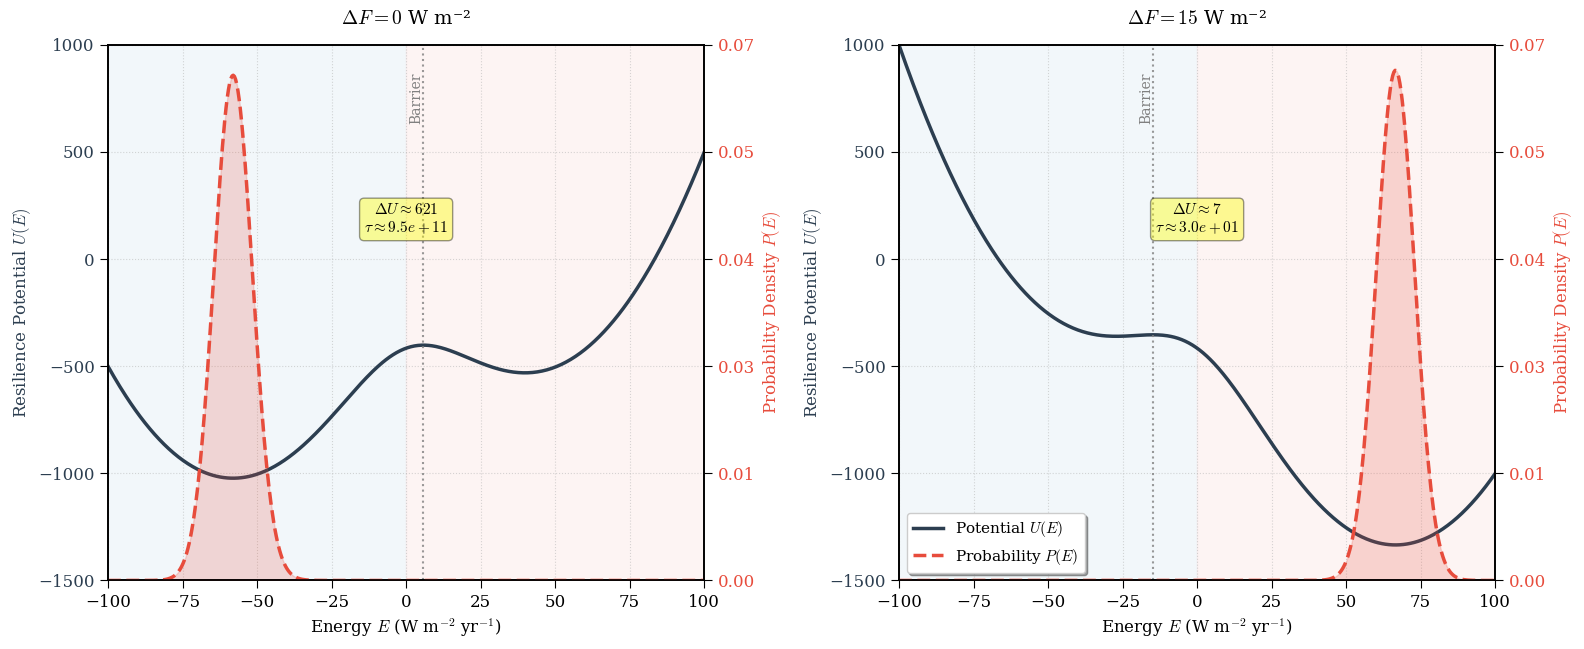

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FormatStrFormatter
from scipy.optimize import fsolve

# ----------------- Enhanced Plot Styling -----------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['mathtext.fontset'] = 'cm'

# ----------------- Model Parameters -----------------
A, B, S = 80.0, 0.6, 150.0
alpha_ice, alpha_ocean, delta_E = 0.7, 0.3, 10.0
SIGMA = 7.0  # Noise amplitude (W m⁻²)

# ----------------- ASI Model Functions -----------------
def albedo(E):
    return alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

def Ein(E):
    return (1 - albedo(E)) * S

def R(E, dF):
    return Ein(E) - (A + B * E - dF)

def dEin_dE(E):
    ex = np.exp(E / delta_E)
    return S * (alpha_ice - alpha_ocean) * ex / (delta_E * (1 + ex)**2)

def U(E, dF):
    term1 = (A - dF - S * (1 - alpha_ocean)) * E
    term2 = (B * E**2) / 2
    log_term = np.log(1 + np.exp(E / delta_E))
    term3 = S * (alpha_ice - alpha_ocean) * (E - delta_E * log_term)
    return term1 + term2 + term3

def d2U_dE2(E):
    return B - dEin_dE(E)

def find_steady_states(dF):
    guesses = [-80, 0, 80]
    roots = set()
    for g in guesses:
        sol, _, flag, _ = fsolve(R, g, args=(dF,), full_output=True)
        if flag == 1:
            roots.add(round(sol[0], 5))
    return sorted(list(roots))

# ----------------- Escape time (Kramers) -----------------
def escape_time_full(dF, sigma):
    """
    Compute mean escape time τ from the ice-covered minimum
    using Kramers' formula in a 1D potential.

    Returns:
        tau      : mean escape time (model units)
        deltaU   : barrier height ΔU
        E_stable : ice-covered stable minimum
        E_saddle : unstable saddle
    """
    roots = find_steady_states(dF)
    stables = [r for r in roots if d2U_dE2(r) > 0]
    unstables = [r for r in roots if d2U_dE2(r) < 0]

    # If there is no saddle or no stable state, no escape problem
    if len(stables) == 0 or len(unstables) == 0:
        return np.nan, np.nan, np.nan, np.nan

    # Take the ice-covered minimum as the leftmost stable state
    E_stable = min(stables)
    E_saddle = unstables[0]

    deltaU = U(E_saddle, dF) - U(E_stable, dF)

    # Local curvatures
    kappa_s = d2U_dE2(E_stable)
    kappa_u = abs(d2U_dE2(E_saddle))

    # Kramers prefactor (1D)
    prefactor = 2 * np.pi / np.sqrt(kappa_s * kappa_u)

    tau = prefactor * np.exp(2 * deltaU / sigma**2)
    return tau, deltaU, E_stable, E_saddle

    
# ----------------- Probability Density Function (Eq. 4.26) -----------------
def prob_density(E_range, dF, sigma):
    unnormalized_prob = np.exp(-2 * U(E_range, dF) / sigma**2)
    Z = np.trapz(unnormalized_prob, E_range)
    return unnormalized_prob / Z if Z > 0 else np.zeros_like(E_range)

# ----------------- Helper: align right-axis ticks to left gridlines -----------------
def align_right_ticks_to_left_grid(ax_left, ax_right):
    """
    Force the right y-axis tick positions to fall exactly on the left axis'
    horizontal gridlines (i.e., same canvas y-positions).
    """
    # Ensure limits are final before reading ticks
    left_min, left_max = ax_left.get_ylim()
    right_min, right_max = ax_right.get_ylim()

    left_ticks = ax_left.get_yticks()
    # Map left tick positions (data units on left axis) to right-axis data units
    ticks_right = ( (left_ticks - left_min) / (left_max - left_min) ) * (right_max - right_min) + right_min

    ax_right.yaxis.set_major_locator(FixedLocator(ticks_right))
    # Optional formatting for small probabilities
    ax_right.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# ----------------- Pre-calc -----------------
E_range = np.linspace(-100, 100, 501)
scenarios = [
    {'dF': 0.0,  'title': '(a) High Resilience'},
    {'dF': 15.0, 'title': '(b) Weakened Resilience'}
]

all_U_vals, all_P_vals = [], []
for sc in scenarios:
    dF = sc['dF']
    all_U_vals.append(U(E_range, dF))
    all_P_vals.append(prob_density(E_range, dF, SIGMA))

# Consistent axis scaling across panels
U_min = -1500   # fixed to match your figure design
U_max = 1000
P_min = 0.0
P_max = max([np.max(p) for p in all_P_vals]) * 1.05

# ----------------- Plot -----------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# fig.suptitle('Stochastic Effects on Arctic Sea Ice Resilience', fontsize=18, fontweight='bold', y=0.98)

legend_handles = None
legend_labels = None

for ax, sc, U_vals, P_vals in zip(axes, scenarios, all_U_vals, all_P_vals):
    dF = sc['dF']

    # Primary axis: Potential
    color_potential = '#2C3E50'
    line_potential, = ax.plot(E_range, U_vals, color=color_potential, lw=2.5, label='Potential $U(E)$')
    ax.set_ylabel('Resilience Potential $U(E)$', color=color_potential, fontsize=12)
    ax.tick_params(axis='y', labelcolor=color_potential)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(-100, 100)
    ax.set_ylim(U_min, U_max)
    ax.set_xlabel('Energy $E$ (W m$^{-2}$ yr$^{-1}$)', fontsize=12)
    # ax.set_title(f"{sc['title']}", fontsize=14, pad=10)
    ax.set_title(f"$\Delta F = {dF:.0f}$ W m⁻²", fontsize=14, pad=15)

    # Background shading
    ax.axvspan(-100, 0, color='#EAF2F8', alpha=0.6, zorder=-1)
    ax.axvspan(0, 100, color='#FDEDEC', alpha=0.6, zorder=-1)

    # Secondary axis: Probability
    ax_prob = ax.twinx()
    color_prob = '#E74C3C'
    line_prob, = ax_prob.plot(E_range, P_vals, color=color_prob, lw=2.5, ls='--', label='Probability $P(E)$')
    ax_prob.fill_between(E_range, P_vals, color=color_prob, alpha=0.2)
    ax_prob.set_ylabel('Probability Density $P(E)$', color=color_prob, fontsize=12)
    ax_prob.tick_params(axis='y', labelcolor=color_prob)
    ax_prob.set_ylim(P_min, P_max)
    ax_prob.grid(False)  # grid comes from the left axis

    # --- Align right ticks to left gridlines ---
    align_right_ticks_to_left_grid(ax, ax_prob)

    # # --- Barrier annotation (if bistable) ---
    # steady_states = find_steady_states(dF)
    # stable_states = [s for s in steady_states if d2U_dE2(s) > 0]
    # unstable_states = [s for s in steady_states if d2U_dE2(s) < 0]
    # if len(stable_states) > 1 and unstable_states:
    #     E_s1, E_s2 = min(stable_states), unstable_states[0]
    #     barrier_height = U(E_s2, dF) - U(E_s1, dF)
    #     ax.axvline(E_s2, color='gray', linestyle=':', alpha=0.8, lw=1.5)
    #     ax.text(E_s2, U_min + (U_max - U_min) * 0.9, 'Barrier',
    #             rotation=90, ha='right', va='center', fontsize=10, color='gray')
    #     ax.text(0.5, 0.65, f'Barrier height:\nΔU ≈ {barrier_height:.0f}',
    #             transform=ax.transAxes, fontsize=11, ha='center',
    #             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4))

    # --- Barrier and escape-time annotation (if bistable) ---
    steady_states = find_steady_states(dF)
    stable_states = [s for s in steady_states if d2U_dE2(s) > 0]
    unstable_states = [s for s in steady_states if d2U_dE2(s) < 0]

    if len(stable_states) > 1 and unstable_states:
        # Ice-covered minimum and saddle
        E_stable = min(stable_states)
        E_saddle = unstable_states[0]

        # Barrier height
        barrier_height = U(E_saddle, dF) - U(E_stable, dF)

        # Escape time (Kramers)
        tau, deltaU_check, _, _ = escape_time_full(dF, SIGMA)

        # Vertical line at the saddle
        ax.axvline(E_saddle, color='gray', linestyle=':', alpha=0.8, lw=1.5)
        ax.text(E_saddle,
                U_min + (U_max - U_min) * 0.9,
                'Barrier',
                rotation=90, ha='right', va='center',
                fontsize=10, color='gray')

        # Annotation box with ΔU and τ
        ax.text(
            0.5, 0.65,
            r'$\Delta U \approx {0:.0f}$'.format(barrier_height)
            + '\n'
            + r'$\tau \approx {0:.1e}$'.format(tau),
            transform=ax.transAxes,
            fontsize=11,
            ha='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4)
        )

    # Keep handles for a single, shared legend
    if legend_handles is None:
        legend_handles = [line_potential, line_prob]
        legend_labels = [h.get_label() for h in legend_handles]

# Shared legend on the right panel
axes[1].legend(legend_handles, legend_labels, loc='lower left',
               fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('stochastic_resilience_plot_aligned.png', dpi=300, bbox_inches='tight')
plt.show()


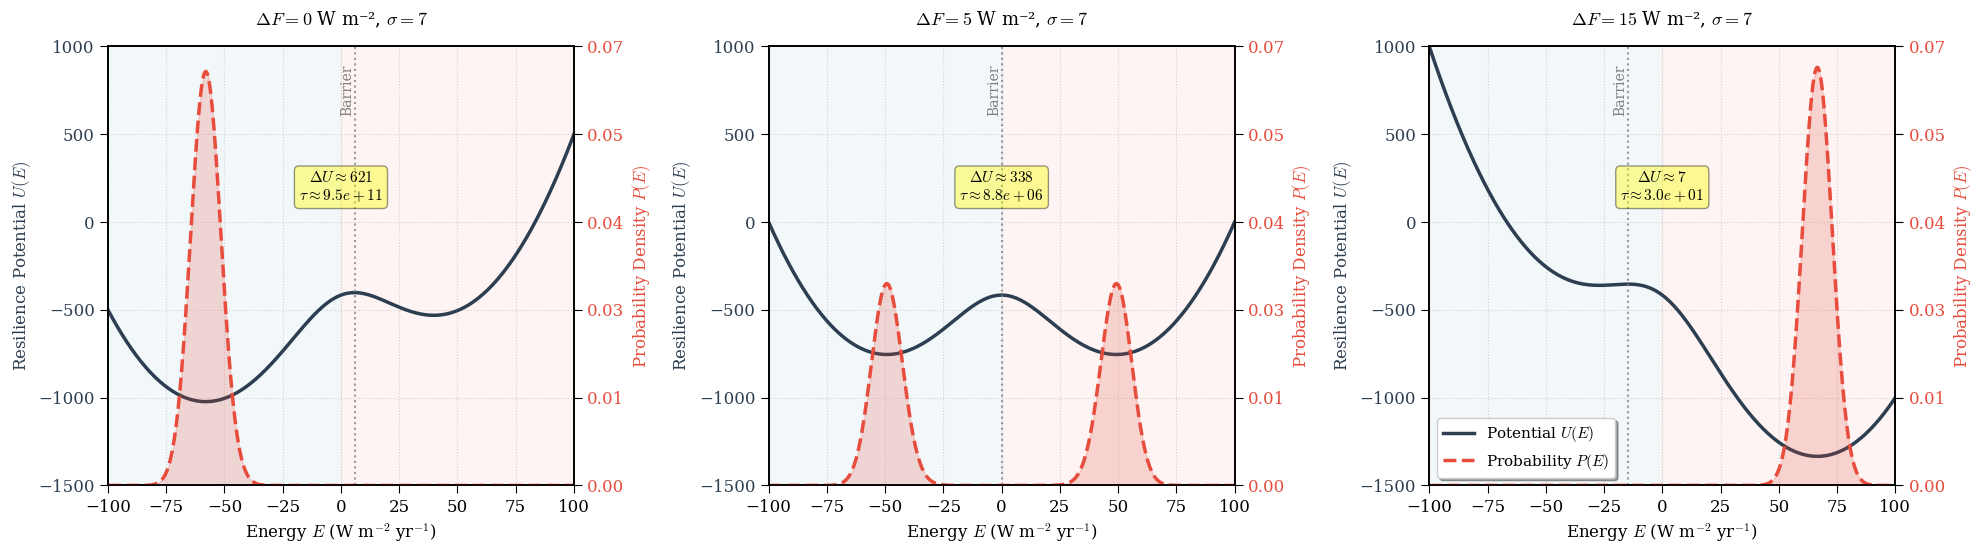

✓ Plot saved as 'asi_resilience_revised.png'

Scenario Summary:

High Resilience:
  ΔF = 0.0 W m⁻²
  Barrier height ΔU ≈ 620.9
  Escape time τ ≈ 9.48e+11
  Ice-covered min: E ≈ -58.03
  Saddle point: E ≈ 5.82

Metastable State:
  ΔF = 5.0 W m⁻²
  Barrier height ΔU ≈ 338.3
  Escape time τ ≈ 8.80e+06
  Ice-covered min: E ≈ -49.28
  Saddle point: E ≈ 0.00

Weakened Resilience:
  ΔF = 15.0 W m⁻²
  Barrier height ΔU ≈ 7.0
  Escape time τ ≈ 3.03e+01
  Ice-covered min: E ≈ -27.09
  Saddle point: E ≈ -14.82


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FormatStrFormatter
from scipy.optimize import fsolve

# ============================================================================
# ENHANCED PLOT STYLING
# ============================================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['mathtext.fontset'] = 'cm'

# ============================================================================
# MODEL PARAMETERS
# ============================================================================
A, B, S = 80.0, 0.6, 150.0
alpha_ice, alpha_ocean, delta_E = 0.7, 0.3, 10.0
SIGMA = 7.0  # Noise amplitude (W m⁻²)

# ============================================================================
# ASI MODEL FUNCTIONS
# ============================================================================
def albedo(E):
    """Smooth sigmoid albedo α(E)."""
    return alpha_ocean + (alpha_ice - alpha_ocean) / (1 + np.exp(E / delta_E))

def Ein(E):
    """Incoming shortwave absorbed by the surface."""
    return (1 - albedo(E)) * S

def R(E, dF):
    """Net energy tendency (deterministic part)."""
    return Ein(E) - (A + B * E - dF)

def dEin_dE(E):
    """Derivative of Ein with respect to E."""
    ex = np.exp(E / delta_E)
    return S * (alpha_ice - alpha_ocean) * ex / (delta_E * (1 + ex)**2)

def U(E, dF):
    """Resilience potential U(E) such that dE/dt = -∂U/∂E + noise."""
    term1 = (A - dF - S * (1 - alpha_ocean)) * E
    term2 = 0.5 * B * E**2
    log_term = np.log(1 + np.exp(E / delta_E))
    term3 = S * (alpha_ice - alpha_ocean) * (E - delta_E * log_term)
    return term1 + term2 + term3

def d2U_dE2(E):
    """Second derivative of potential: local curvature."""
    return B - dEin_dE(E)

def find_steady_states(dF):
    """Find equilibria R(E, dF) = 0 for a given forcing ΔF."""
    guesses = [-80, 0, 80]
    roots = set()
    for g in guesses:
        sol, _, flag, _ = fsolve(R, g, args=(dF,), full_output=True)
        if flag == 1:
            roots.add(round(float(sol[0]), 5))
    return sorted(list(roots))

# ============================================================================
# ESCAPE TIME (KRAMERS FORMULA)
# ============================================================================
def escape_time_full(dF, sigma):
    """
    Compute mean escape time τ from the ice-covered minimum
    using Kramers' formula in a 1D potential.

    Returns:
        tau      : mean escape time (model units)
        deltaU   : barrier height ΔU
        E_stable : ice-covered stable minimum
        E_saddle : unstable saddle
    """
    roots = find_steady_states(dF)
    stables = [r for r in roots if d2U_dE2(r) > 0]
    unstables = [r for r in roots if d2U_dE2(r) < 0]

    # If there is no saddle or no stable state, no escape problem
    if len(stables) == 0 or len(unstables) == 0:
        return np.nan, np.nan, np.nan, np.nan

    # Take the ice-covered minimum as the leftmost stable state
    E_stable = min(stables)
    E_saddle = unstables[0]

    deltaU = U(E_saddle, dF) - U(E_stable, dF)

    # Local curvatures
    kappa_s = d2U_dE2(E_stable)
    kappa_u = abs(d2U_dE2(E_saddle))

    # Kramers prefactor (1D)
    prefactor = 2 * np.pi / np.sqrt(kappa_s * kappa_u)

    tau = prefactor * np.exp(2 * deltaU / sigma**2)
    return tau, deltaU, E_stable, E_saddle

# ============================================================================
# PROBABILITY DENSITY FUNCTION
# ============================================================================
def prob_density(E_range, dF, sigma):
    """
    Stationary PDF for 1D Langevin dynamics in potential U(E):
        P(E) ∝ exp(-2 U(E)/σ²)
    """
    unnormalized = np.exp(-2 * U(E_range, dF) / sigma**2)
    Z = np.trapezoid(unnormalized, E_range)
    if Z <= 0:
        return np.zeros_like(E_range)
    return unnormalized / Z

# ============================================================================
# HELPER: ALIGN RIGHT-AXIS TICKS TO LEFT GRIDLINES
# ============================================================================
def align_right_ticks_to_left_grid(ax_left, ax_right):
    """
    Force the right y-axis tick positions to fall exactly on the left axis'
    horizontal gridlines (i.e., same canvas y-positions).
    """
    left_min, left_max = ax_left.get_ylim()
    right_min, right_max = ax_right.get_ylim()

    left_ticks = ax_left.get_yticks()
    # Map left tick positions (data units on left axis) to right-axis data units
    ticks_right = ((left_ticks - left_min) / (left_max - left_min)) * (right_max - right_min) + right_min

    ax_right.yaxis.set_major_locator(FixedLocator(ticks_right))
    ax_right.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# ============================================================================
# PRE-CALCULATION
# ============================================================================
E_range = np.linspace(-100, 100, 501)

scenarios = [
    {'dF': 0.0,  'sigma': 7.0,  'panel': '(a)', 'title': 'High Resilience'},
    {'dF': 5.0,  'sigma': 7.0, 'panel': '(b)', 'title': 'Metastable State'},
    {'dF': 15.0, 'sigma': 7.0,  'panel': '(c)', 'title': 'Weakened Resilience'}
]

all_U_vals, all_P_vals = [], []
for sc in scenarios:
    dF, sigma = sc['dF'], sc['sigma']
    all_U_vals.append(U(E_range, dF))
    all_P_vals.append(prob_density(E_range, dF, sigma))

# Consistent axis scaling across panels
U_min = -1500
U_max = 1000
P_min = 0.0
P_max = max([np.max(p) for p in all_P_vals]) * 1.05

# ============================================================================
# MAIN PLOT
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

legend_handles = None
legend_labels = None

for ax, sc, U_vals, P_vals in zip(axes, scenarios, all_U_vals, all_P_vals):
    dF = sc['dF']
    sigma = sc['sigma']

    # --- PRIMARY AXIS: POTENTIAL ---
    color_potential = '#2C3E50'
    line_potential, = ax.plot(E_range, U_vals, color=color_potential, lw=2.5, 
                               label='Potential $U(E)$')
    ax.set_ylabel('Resilience Potential $U(E)$', color=color_potential, fontsize=12)
    ax.tick_params(axis='y', labelcolor=color_potential)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(-100, 100)
    ax.set_ylim(U_min, U_max)
    ax.set_xlabel('Energy $E$ (W m$^{-2}$ yr$^{-1}$)', fontsize=12)
    ax.set_title(f"$\\Delta F = {dF:.0f}$ W m⁻², $\\sigma = {sigma:.0f}$", fontsize=13, pad=15)

    # --- BACKGROUND SHADING ---
    ax.axvspan(-100, 0, color='#EAF2F8', alpha=0.6, zorder=-1, label='Ice-covered')
    ax.axvspan(0, 100, color='#FDEDEC', alpha=0.6, zorder=-1, label='Ice-free')

    # --- SECONDARY AXIS: PROBABILITY ---
    ax_prob = ax.twinx()
    color_prob = '#E74C3C'
    line_prob, = ax_prob.plot(E_range, P_vals, color=color_prob, lw=2.5, ls='--', 
                               label='Probability $P(E)$')
    ax_prob.fill_between(E_range, P_vals, color=color_prob, alpha=0.2)
    ax_prob.set_ylabel('Probability Density $P(E)$', color=color_prob, fontsize=12)
    ax_prob.tick_params(axis='y', labelcolor=color_prob)
    ax_prob.set_ylim(P_min, P_max)
    ax_prob.grid(False)

    # --- ALIGN RIGHT TICKS TO LEFT GRIDLINES ---
    align_right_ticks_to_left_grid(ax, ax_prob)

    # --- BARRIER AND ESCAPE-TIME ANNOTATION (if bistable) ---
    steady_states = find_steady_states(dF)
    stable_states = [s for s in steady_states if d2U_dE2(s) > 0]
    unstable_states = [s for s in steady_states if d2U_dE2(s) < 0]

    if len(stable_states) > 1 and unstable_states:
        # Ice-covered minimum and saddle
        E_stable = min(stable_states)
        E_saddle = unstable_states[0]

        # Barrier height
        barrier_height = U(E_saddle, dF) - U(E_stable, dF)

        # Escape time (Kramers)
        tau, deltaU_check, _, _ = escape_time_full(dF, sigma)

        # Vertical line at the saddle
        ax.axvline(E_saddle, color='gray', linestyle=':', alpha=0.8, lw=1.5)
        ax.text(E_saddle,
                U_min + (U_max - U_min) * 0.9,
                'Barrier',
                rotation=90, ha='right', va='center',
                fontsize=10, color='gray')

        # Annotation box with ΔU and τ
        ax.text(
            0.5, 0.65,
            r'$\Delta U \approx {0:.0f}$'.format(barrier_height)
            + '\n'
            + r'$\tau \approx {0:.1e}$'.format(tau),
            transform=ax.transAxes,
            fontsize=11,
            ha='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4)
        )

    # Keep handles for a single, shared legend
    if legend_handles is None:
        legend_handles = [line_potential, line_prob]
        legend_labels = [h.get_label() for h in legend_handles]

# --- SHARED LEGEND ---
axes[-1].legend(legend_handles, legend_labels, loc='lower left',
               fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('asi_resilience_revised.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved as 'asi_resilience_revised.png'")
print("\nScenario Summary:")
for sc in scenarios:
    dF, sigma = sc['dF'], sc['sigma']
    tau, deltaU, E_stable, E_saddle = escape_time_full(dF, sigma)
    print(f"\n{sc['title']}:")
    print(f"  ΔF = {dF} W m⁻²")
    print(f"  Barrier height ΔU ≈ {deltaU:.1f}")
    print(f"  Escape time τ ≈ {tau:.2e}")
    print(f"  Ice-covered min: E ≈ {E_stable:.2f}")
    print(f"  Saddle point: E ≈ {E_saddle:.2f}")